# 8_maincelltype_annotation_withcontrol.py

In [ ]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import os
from collections import Counter
from sklearn.decomposition import PCA

#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


working_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
output_path="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/"
os.chdir(working_dic)


#color key define
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#4C4DB7"])

In [ ]:
#read in qc filtered and doublet removed scanpy object
adata_raw=sc.read("Humanxeno_preprocessed_mtfilter_1_ribofilter.h5ad")
print(adata_raw)

adata=adata_raw
adata
adata.obs_names_make_unique()

AnnData object with n_obs × n_vars = 20289 × 36545
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo'
    var: 'gene_ids', 'feature_types', 'genome', 'hs_mt', 'ss_mt', 'hs_ribo', 'ss_ribo', 'n_cells_by_counts', 'mean_

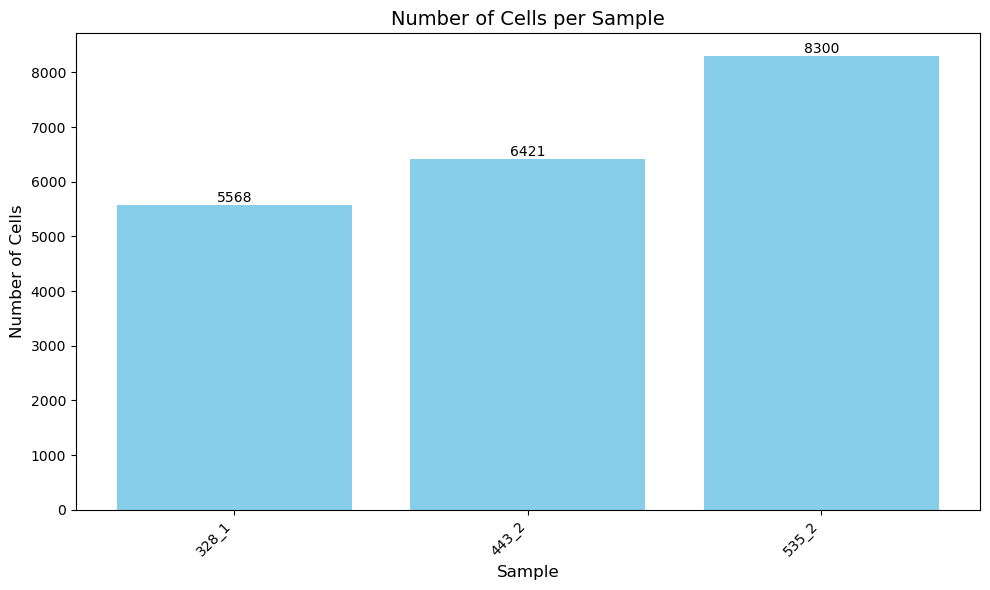

In [ ]:
#check the number of nuclei after filters
sample_column = 'sample'
if sample_column not in adata.obs:
    raise ValueError(f"Column '{sample_column}' not found in adata.obs")

cell_counts = adata.obs[sample_column].value_counts()

cell_counts_df = pd.DataFrame({
    'Sample': cell_counts.index,
    'Cell Count': cell_counts.values
}).sort_values(by='Sample')

plt.figure(figsize=(10, 6))
bars = plt.bar(cell_counts_df['Sample'], cell_counts_df['Cell Count'], color='skyblue')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.title('Number of Cells per Sample', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_31462/1370553351.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_expression_sums = adata.obs.groupby(sample_column).apply(
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_31462/1370553351.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gene_expression_sums = adata.obs.groupby(sample_column).apply(


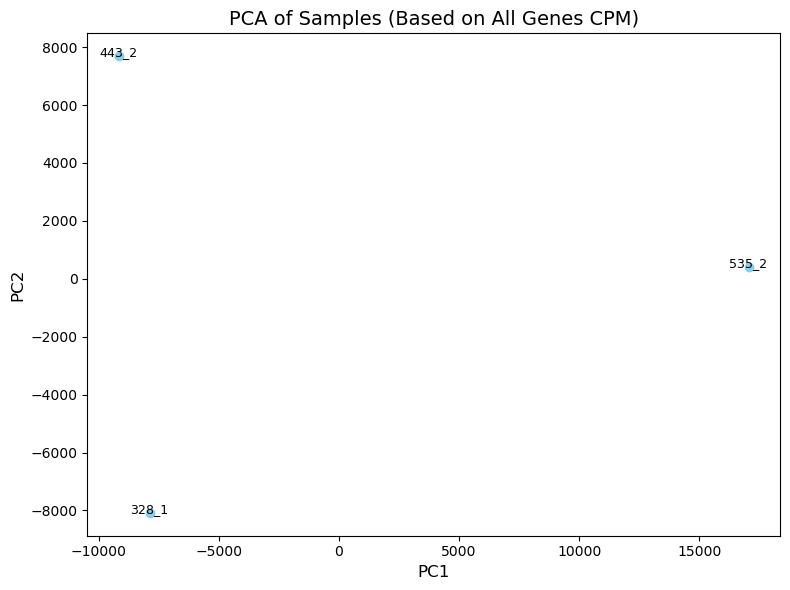

In [ ]:
sample_column = 'sample'

if sample_column not in adata.obs:
    raise ValueError(f"Column '{sample_column}' not found in adata.obs")

gene_expression_sums = adata.obs.groupby(sample_column).apply(
    lambda df: adata[df.index, :].X.sum(axis=0)
)

gene_expression_sums = pd.DataFrame(
    data=np.vstack(gene_expression_sums.values),
    index=gene_expression_sums.index,
    columns=adata.var_names
)

total_expression_per_sample = gene_expression_sums.sum(axis=1)
cpm_normalized = gene_expression_sums.div(total_expression_per_sample, axis=0) * 1e6

pca = PCA(n_components=2)
pca_results = pca.fit_transform(cpm_normalized)

pca_df = pd.DataFrame(
    data=pca_results,
    columns=['PC1', 'PC2'],
    index=gene_expression_sums.index
)

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color='skyblue')
for i, sample in enumerate(pca_df.index):
    plt.text(pca_df.iloc[i, 0], pca_df.iloc[i, 1], sample, fontsize=9, ha='center')
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('PCA of Samples (Based on All Genes CPM)', fontsize=14)
plt.tight_layout()
plt.show()

## 1. Remove batch effects

/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


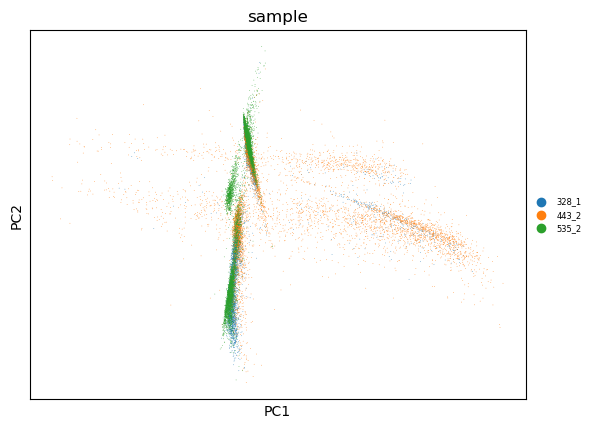

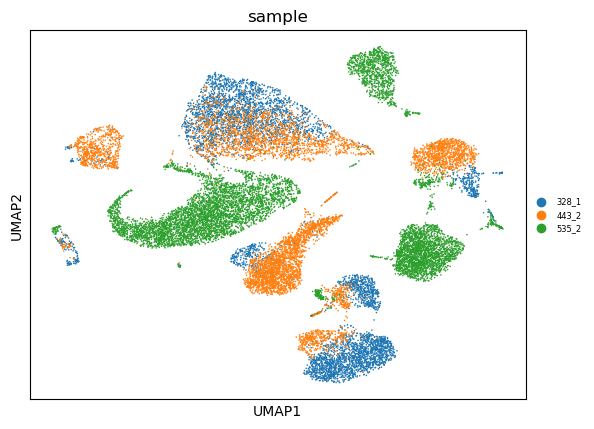

In [ ]:
#######before batch effect remover
adata_beforeinte=adata.copy()

sc.pp.normalize_total(adata_beforeinte)
sc.pp.log1p(adata_beforeinte)

#identify highly variable genes 
sc.pp.highly_variable_genes(adata_beforeinte, flavor="seurat_v3")
adata_beforeinte.raw=adata_beforeinte
adata_beforeinte=adata_beforeinte[:, adata_beforeinte.var.highly_variable]
sc.pp.regress_out(adata_beforeinte, ["total_counts", "pct_counts_hs_mt", "pct_counts_ss_mt"])

cells_hvg=adata_beforeinte
cells_hvg.shape
sc.pp.scale(cells_hvg, max_value=10)
sc.pp.pca(cells_hvg, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(cells_hvg, n_neighbors=10, n_pcs=40)
sc.tl.umap(cells_hvg)
sc.pl.pca_scatter(cells_hvg, color=["sample"], size = 1, legend_fontsize = 6)

sc.pl.umap(cells_hvg, color=["sample"], size = 5, legend_fontsize = 6)

/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


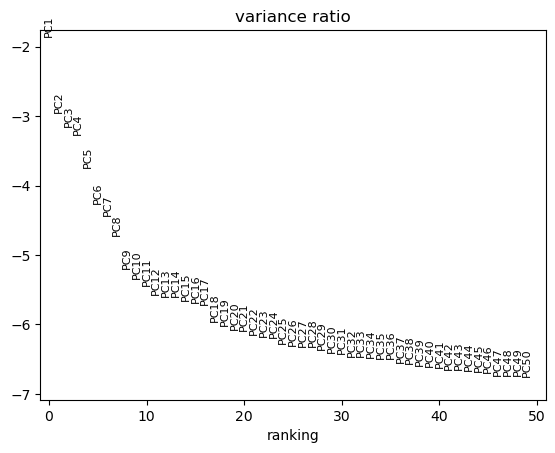

In [ ]:
#######after batch effect remover
adata_afterinte=adata.copy()

sc.pp.normalize_total(adata_afterinte)
sc.pp.log1p(adata_afterinte)

#identify highly variable genes 
sc.pp.highly_variable_genes(adata_afterinte, flavor="seurat_v3")
adata_afterinte.raw=adata_afterinte
adata_afterinte=adata_afterinte[:, adata_afterinte.var['highly_variable']]

sc.pp.regress_out(adata_beforeinte, ["total_counts", "pct_counts_hs_mt", "pct_counts_ss_mt"])
sc.pp.scale(adata_afterinte, max_value=10)

sc.pp.pca(adata_afterinte, n_comps=50, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_afterinte, log=True, n_pcs=50)

2025-09-10 12:21:21,212 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
2025-09-10 12:21:24,148 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-10 12:21:24,274 - harmonypy - INFO - Iteration 1 of 10
2025-09-10 12:21:29,605 - harmonypy - INFO - Iteration 2 of 10
2025-09-10 12:21:34,898 - harmonypy - INFO - Iteration 3 of 10
2025-09-10 12:21:40,226 - harmonypy - INFO - Iteration 4 of 10
2025-09-10 12:21:45,727 -

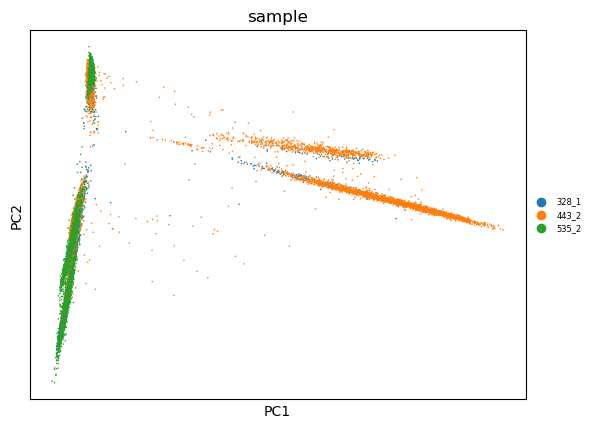

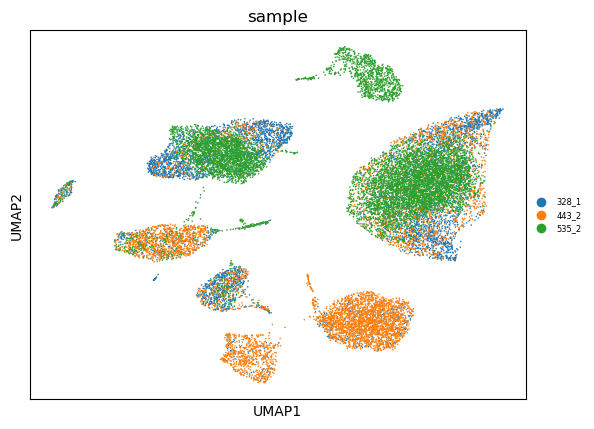

In [ ]:
#run harmony
sc.external.pp.harmony_integrate(adata_afterinte, "sample", random_state=15, epsilon_cluster=-np.inf, epsilon_harmony=-np.inf)

sc.pp.neighbors(adata_afterinte, n_neighbors=15, n_pcs=25, use_rep="X_pca_harmony")
sc.tl.umap(adata_afterinte)
sc.pl.pca_scatter(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)
sc.pl.umap(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)

## 2. Clustering

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_31462/1687655437.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_afterinte, resolution = 0.6 ,key_added="leiden_06")


KeyError: 'leiden_09'

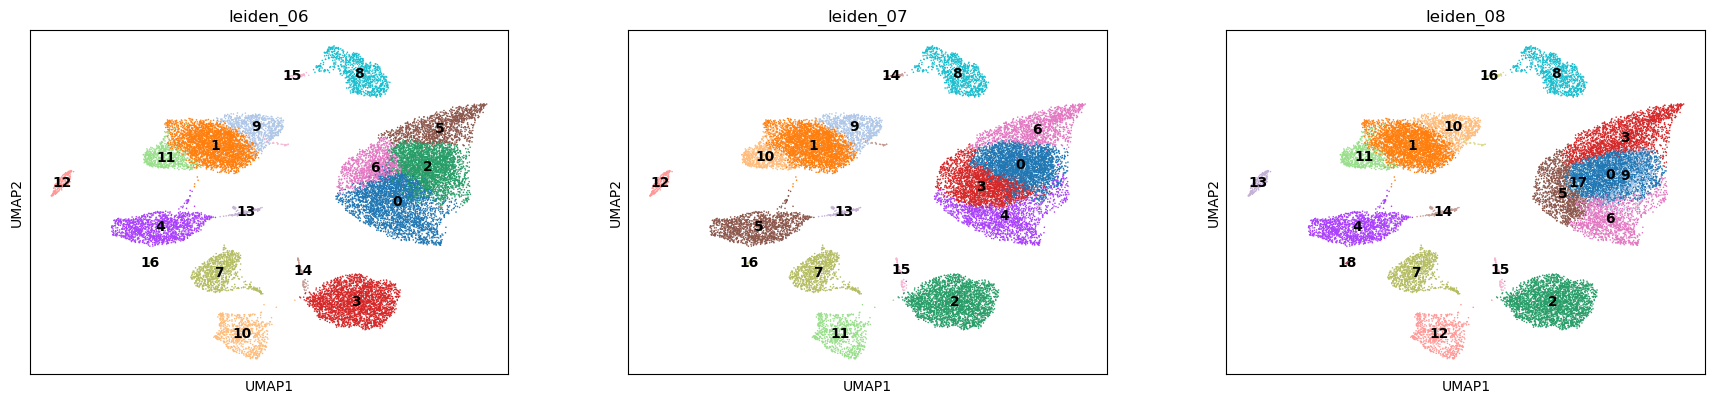

In [ ]:
sc.tl.leiden(adata_afterinte, resolution = 0.6 ,key_added="leiden_06")
sc.tl.leiden(adata_afterinte, resolution = 0.7 ,key_added="leiden_07")
sc.tl.leiden(adata_afterinte, resolution = 0.8 ,key_added="leiden_08")
sc.tl.leiden(adata_afterinte, resolution = 1.0 ,key_added="leiden_10")
sc.tl.leiden(adata_afterinte, resolution = 1.3 ,key_added="leiden_13")
sc.tl.leiden(adata_afterinte, resolution = 1.5 ,key_added="leiden_15")
sc.tl.leiden(adata_afterinte, resolution = 1.7 ,key_added="leiden_17")
sc.tl.leiden(adata_afterinte, resolution = 1.9 ,key_added="leiden_19")


sc.pl.umap(
    adata_afterinte,
    color=["leiden_06", "leiden_07", "leiden_08", "leiden_09", "leiden_10", "leiden_13", "leiden_15", "leiden_17", "leiden_19"],
    legend_loc="on data",
    size=5
)

## 3. Marker gene expression

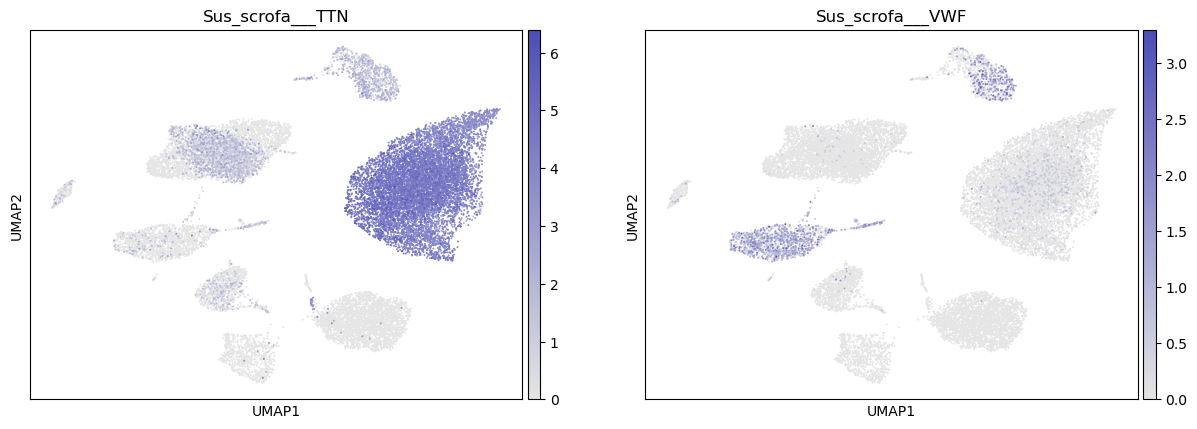

In [ ]:
#######cardiomyocytes
marker=["Sus_scrofa___TTN", "Sus_scrofa___VWF"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

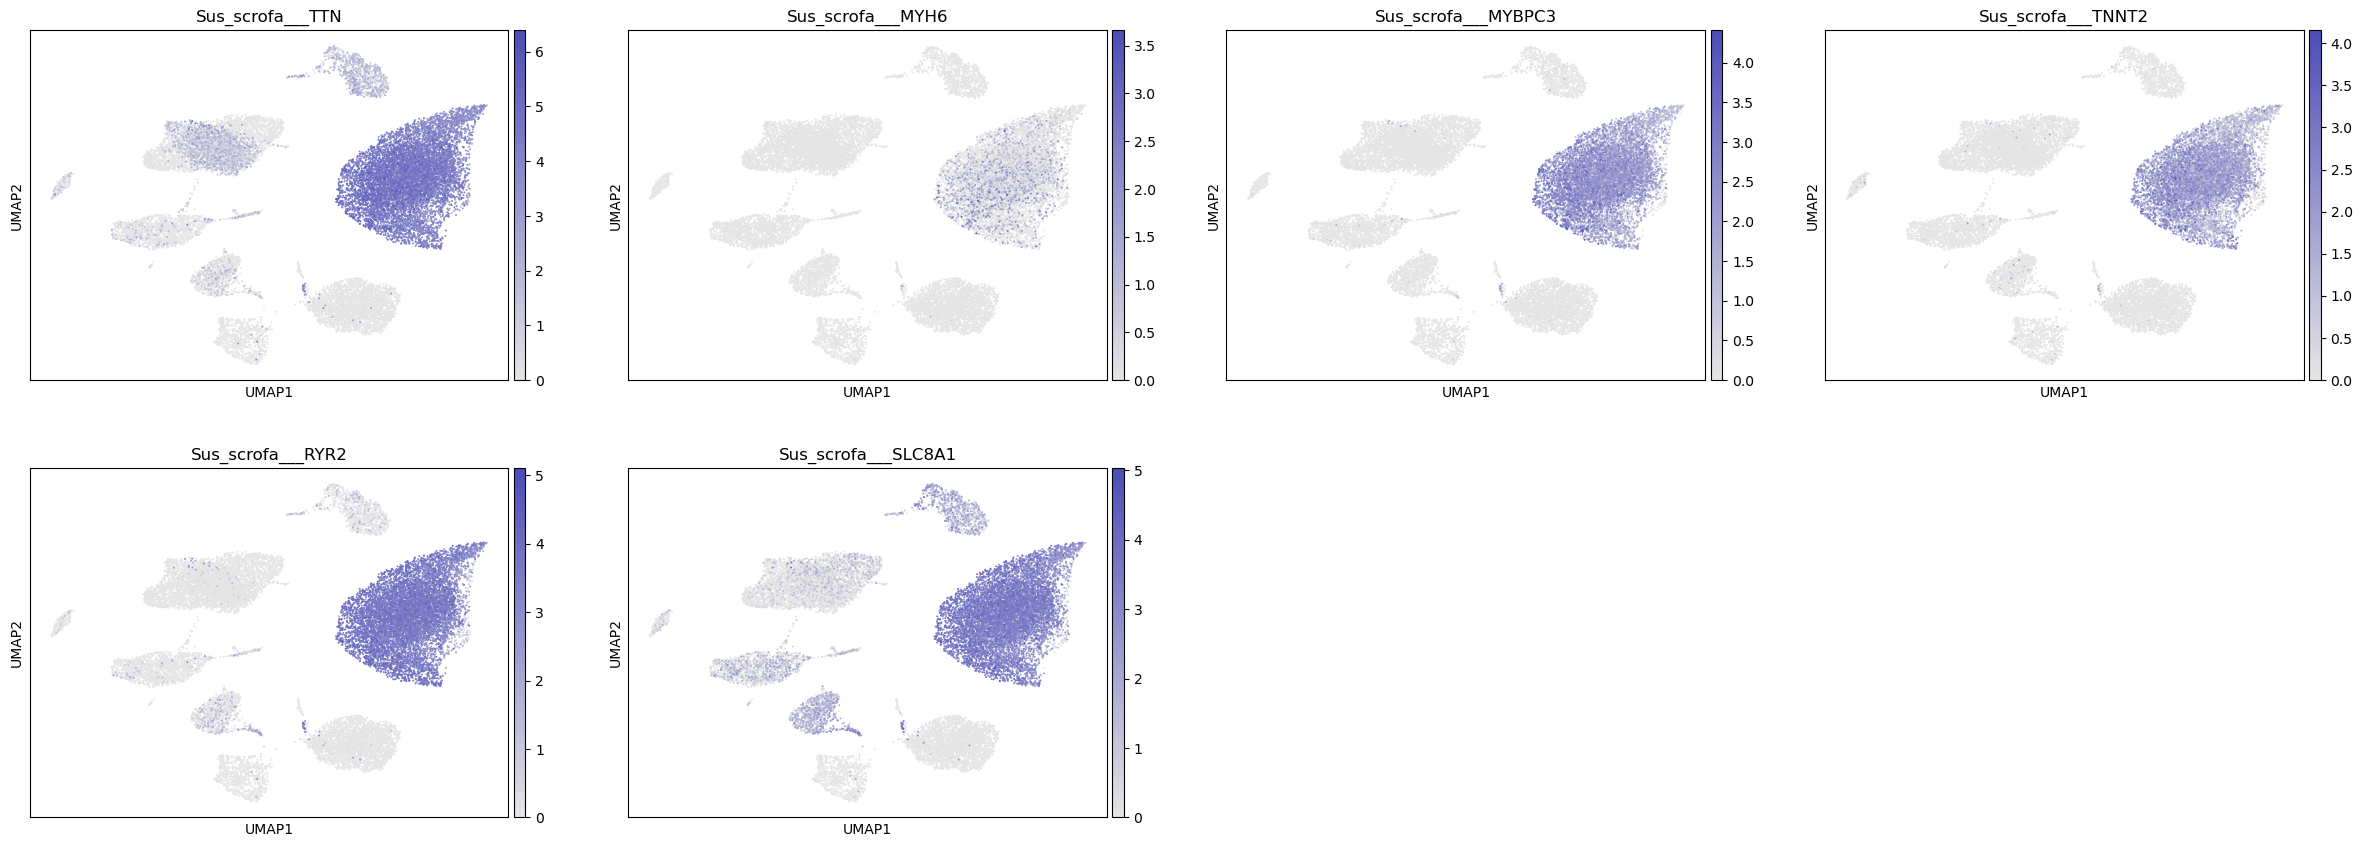

In [ ]:
#######cardiomyocytes
marker=["Sus_scrofa___TTN", "Sus_scrofa___MYH6", "Sus_scrofa___MYBPC3", "Sus_scrofa___TNNT2", "Sus_scrofa___RYR2", "Sus_scrofa___SLC8A1"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

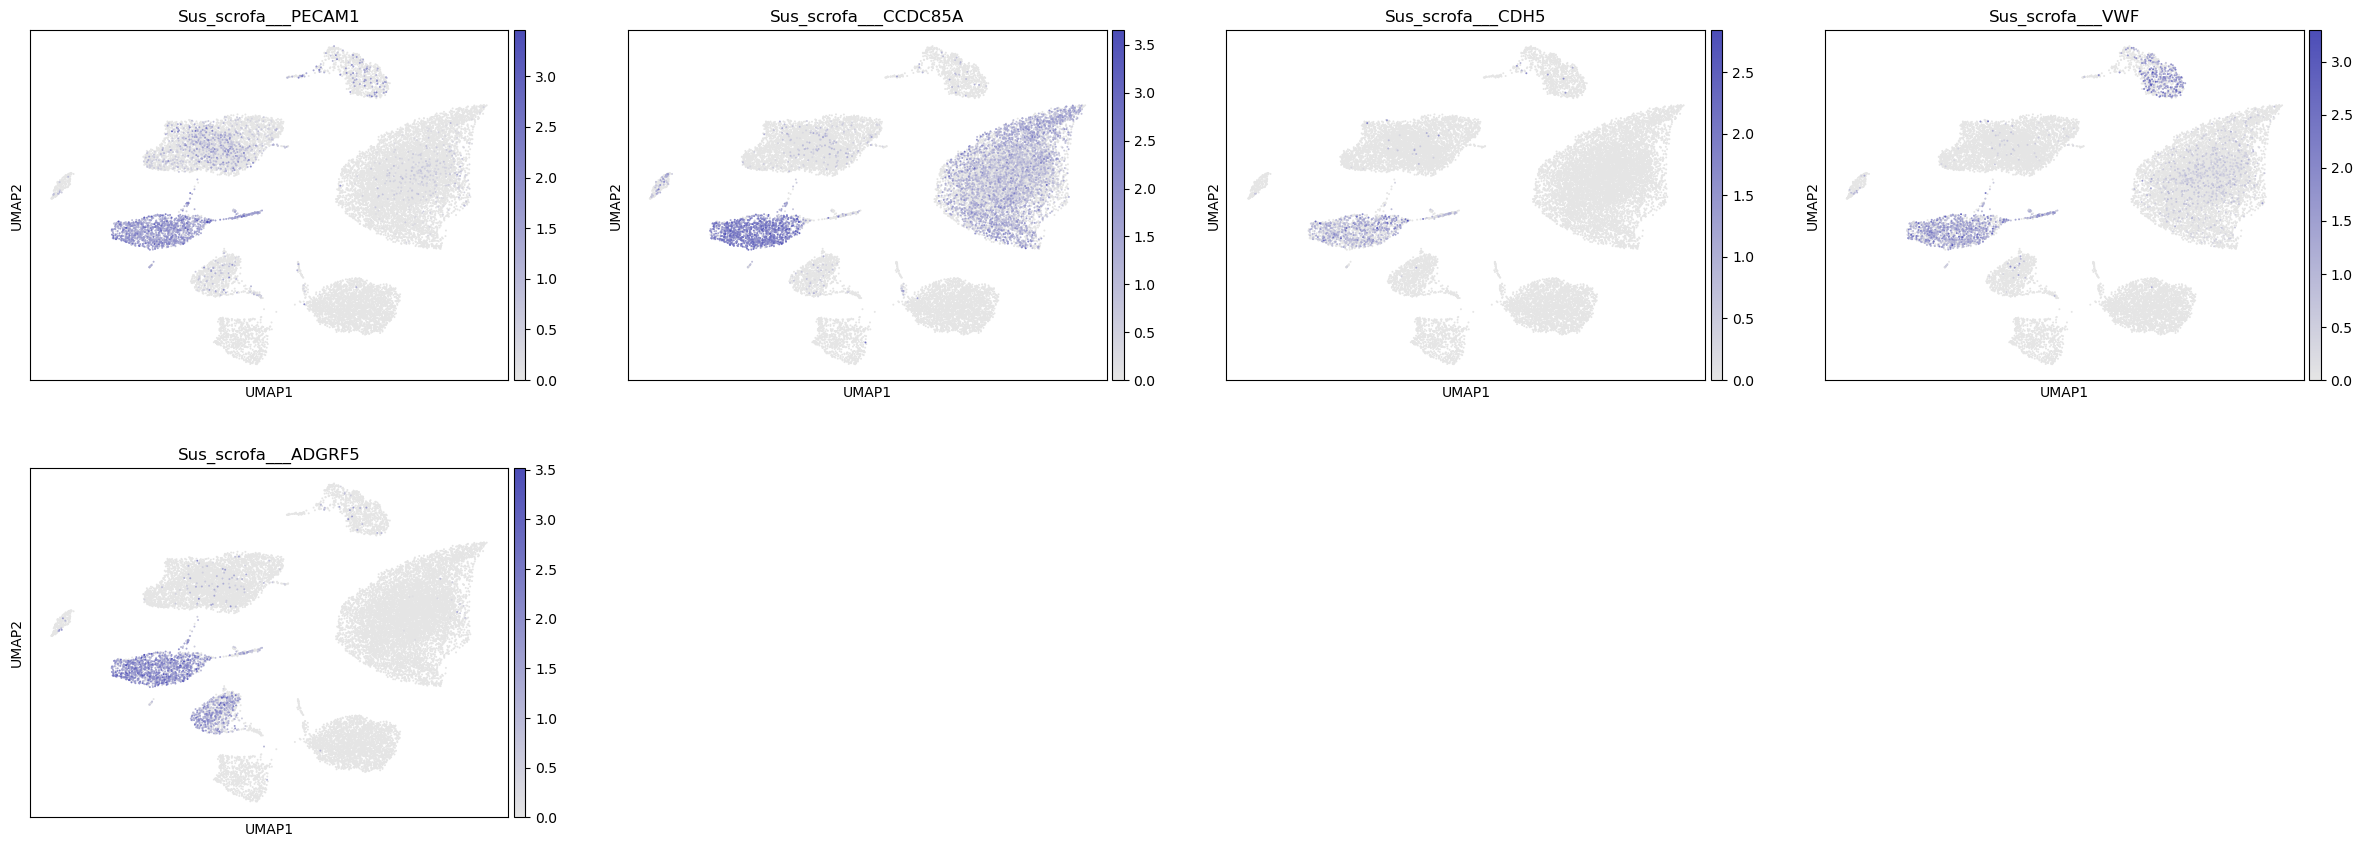

KeyError: 'Homo_sapiens_ADGRF5'

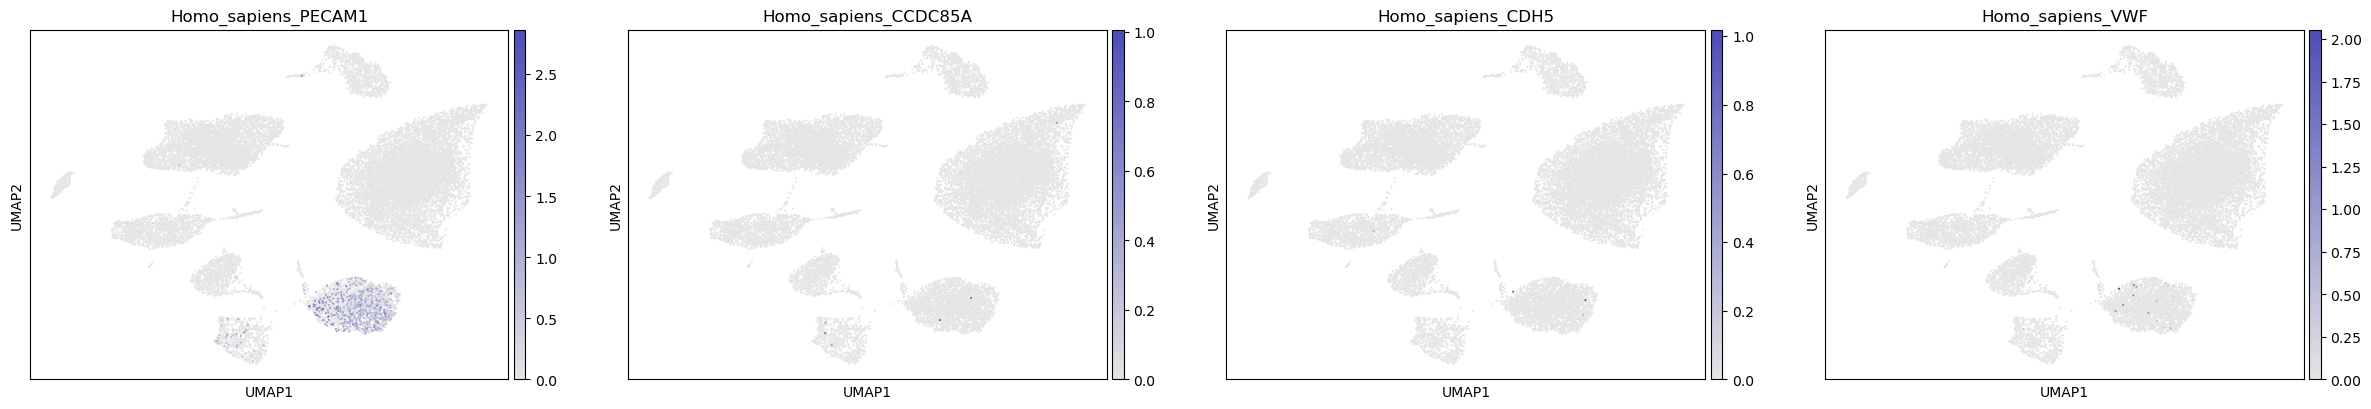

In [ ]:
#######endothelial cells
marker=["Sus_scrofa___PECAM1", "Sus_scrofa___CCDC85A", "Sus_scrofa___CDH5", "Sus_scrofa___VWF", "Sus_scrofa___ADGRF5"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

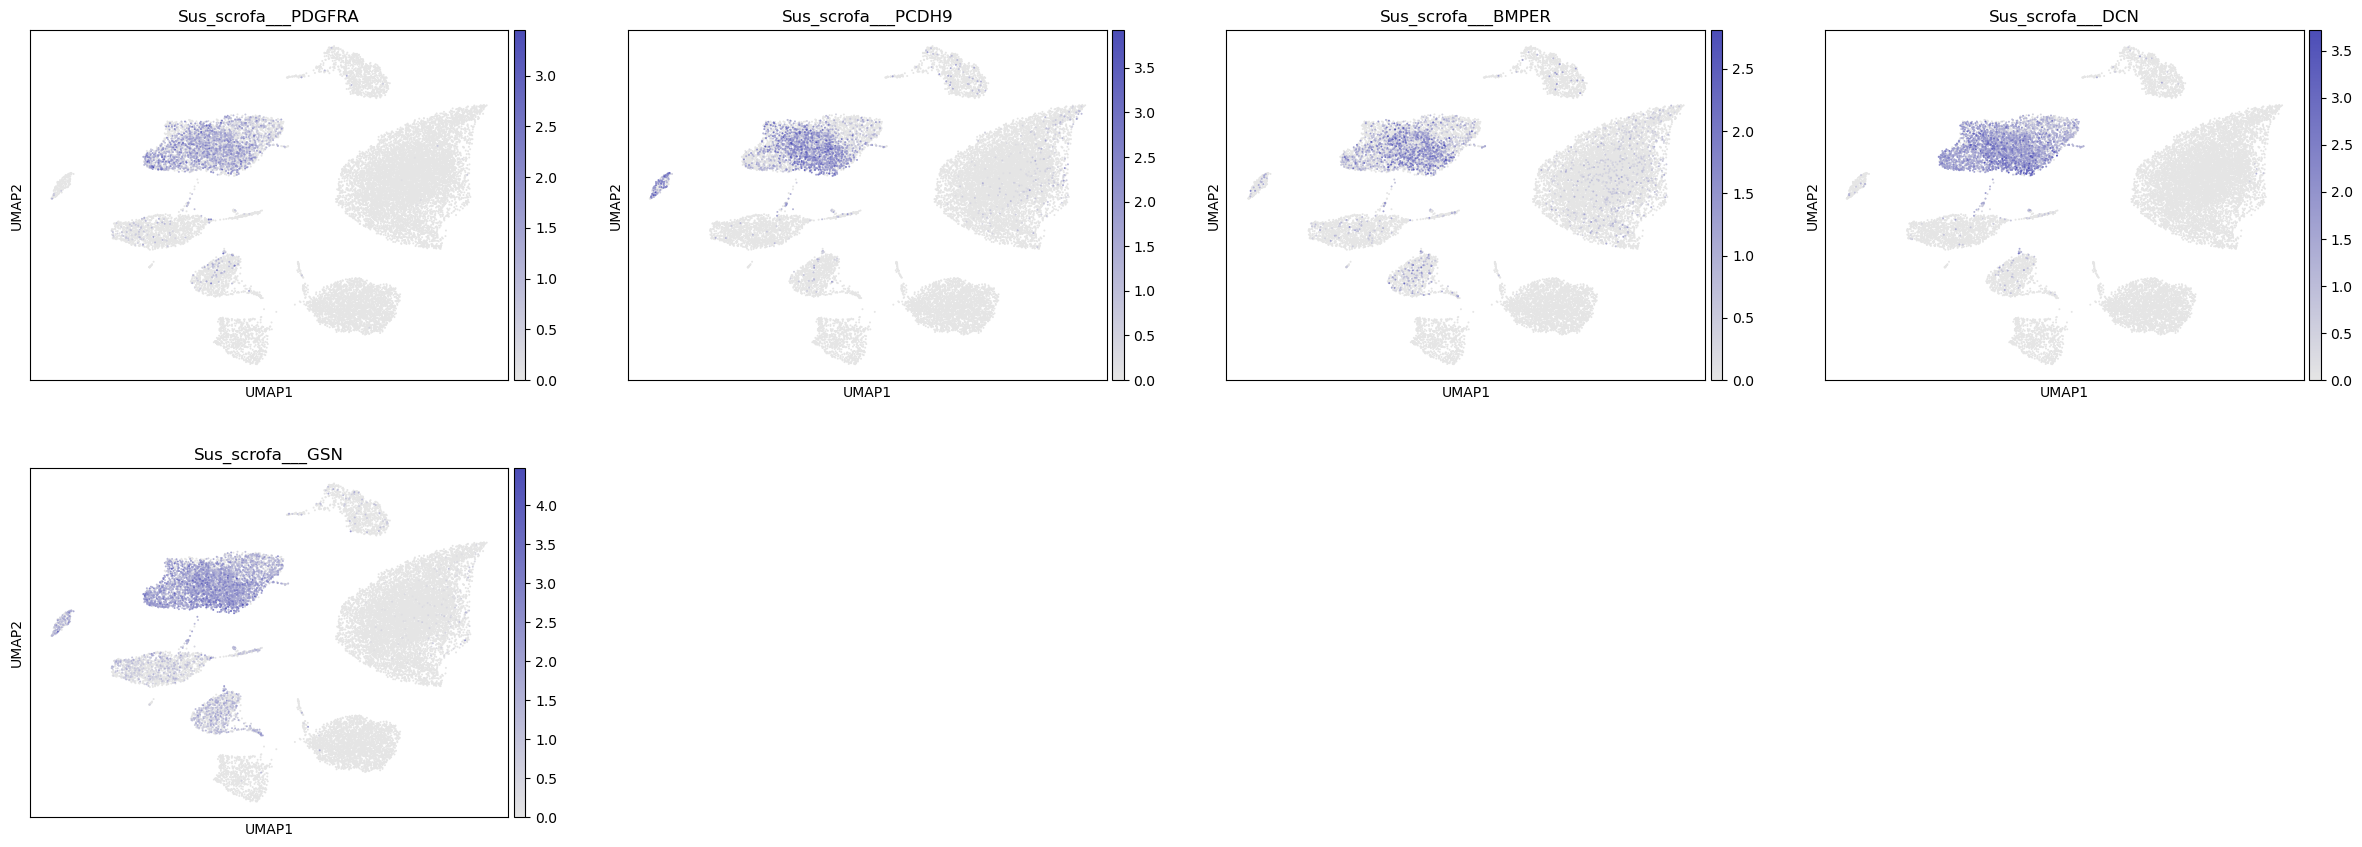

In [ ]:
#######fibroblast
marker=["Sus_scrofa___PDGFRA", "Sus_scrofa___PCDH9", "Sus_scrofa___BMPER", "Sus_scrofa___DCN", "Sus_scrofa___GSN"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

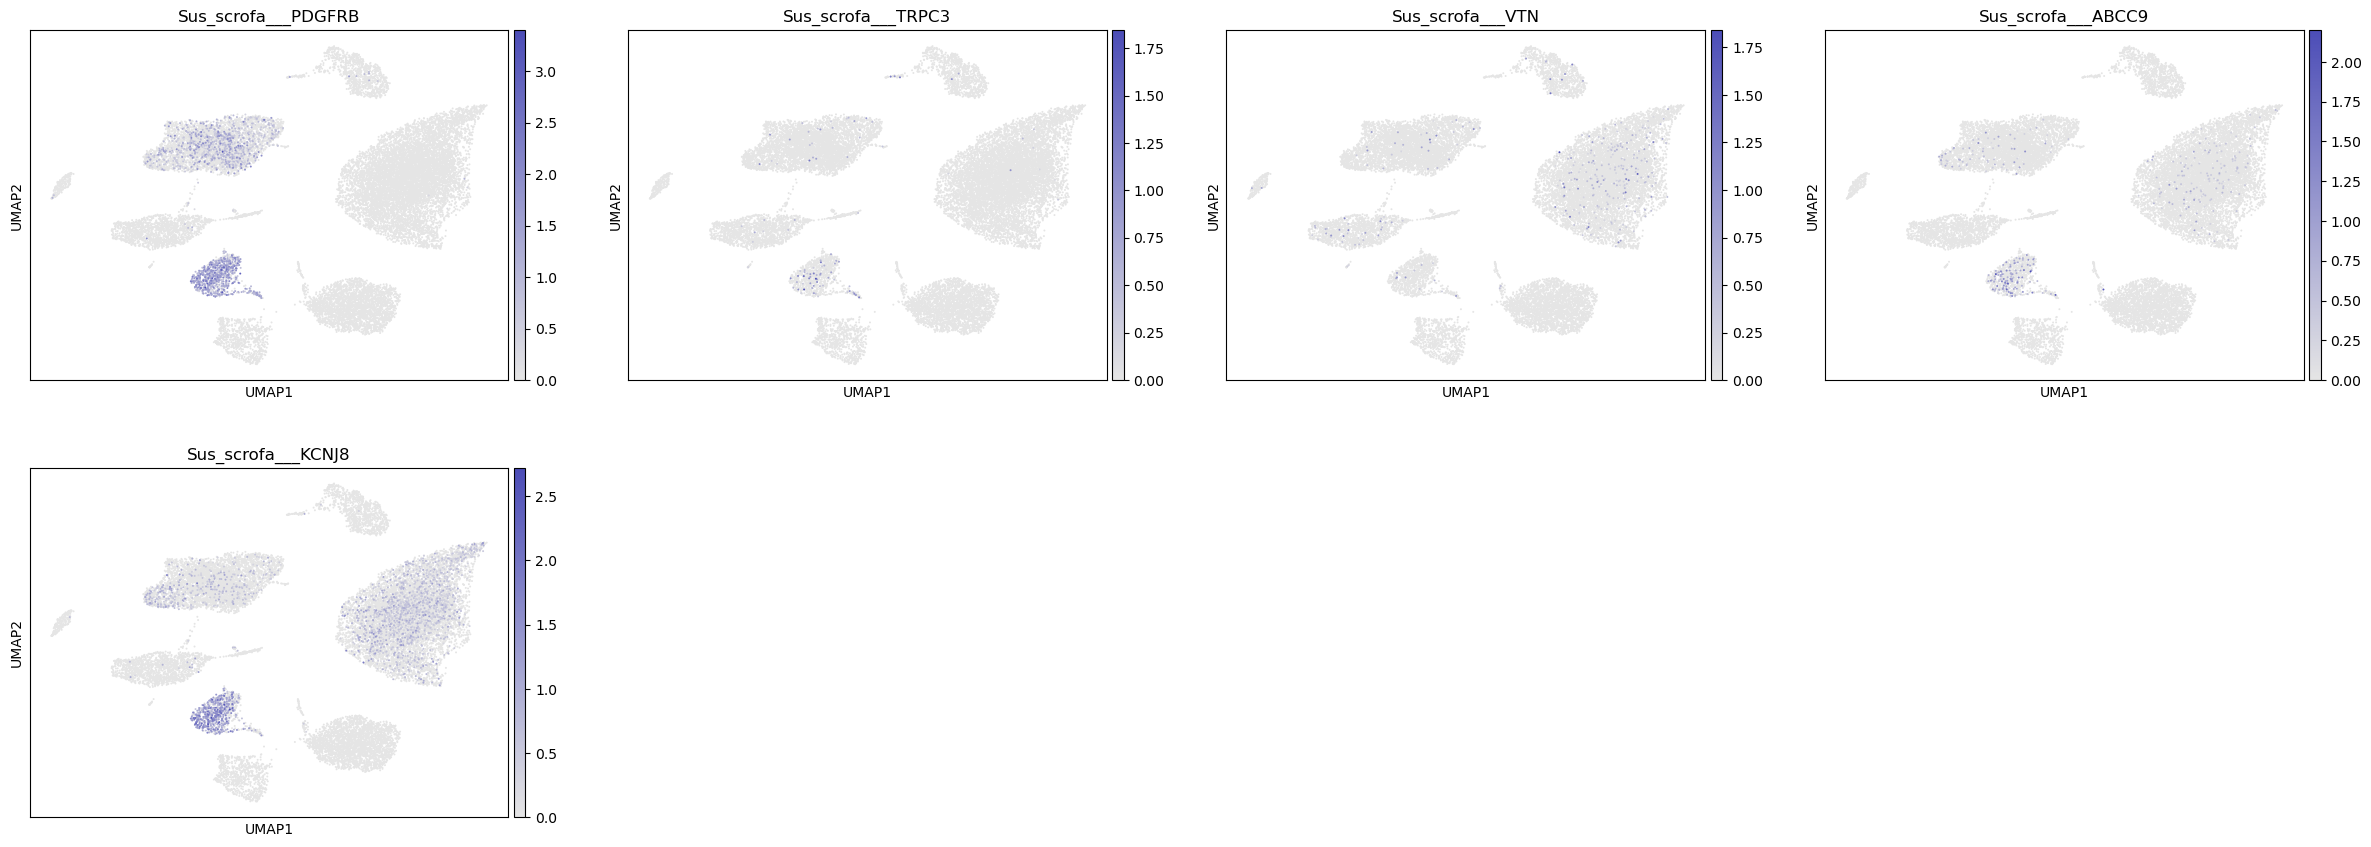

In [ ]:
#######pericytes
marker=["Sus_scrofa___PDGFRB", "Sus_scrofa___TRPC3", "Sus_scrofa___VTN", "Sus_scrofa___ABCC9", "Sus_scrofa___KCNJ8"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

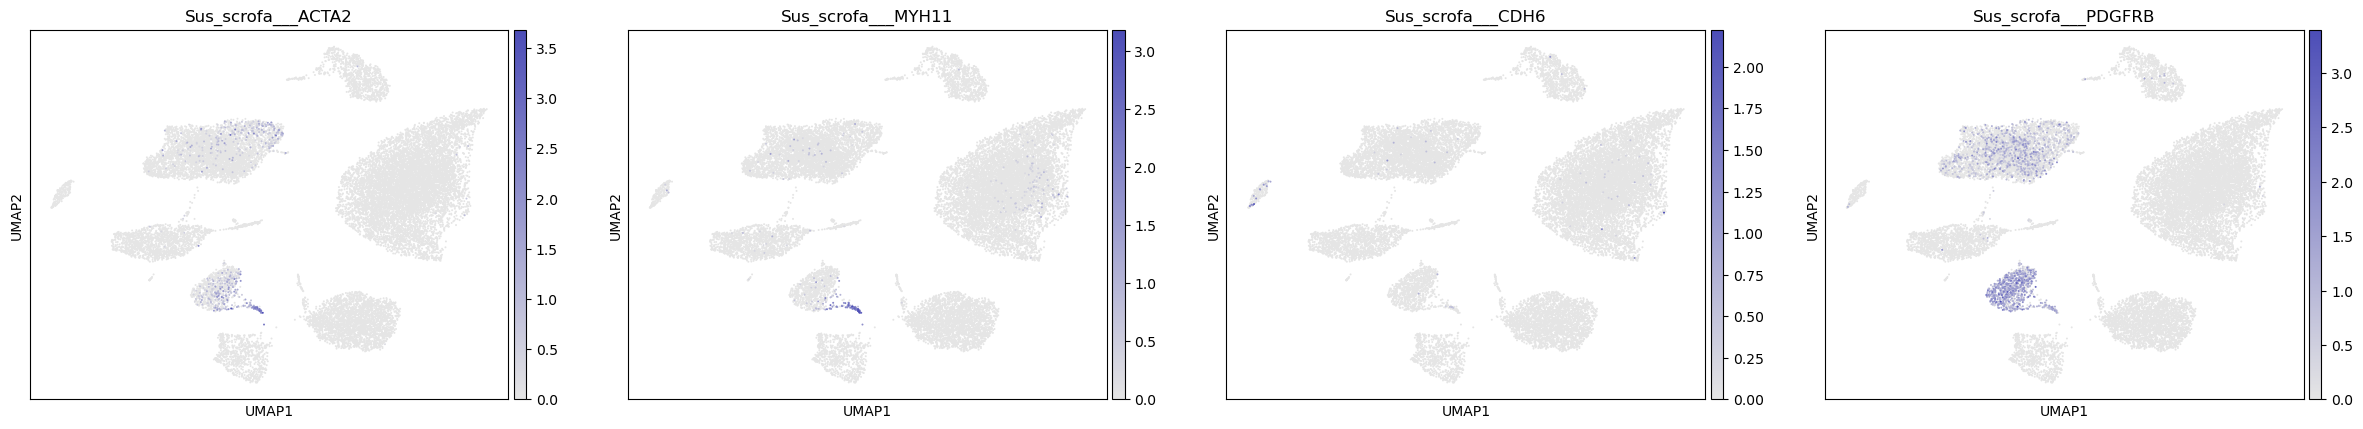

In [ ]:
#######smc
marker=["Sus_scrofa___ACTA2", "Sus_scrofa___MYH11", "Sus_scrofa___CDH6", "Sus_scrofa___PDGFRB"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

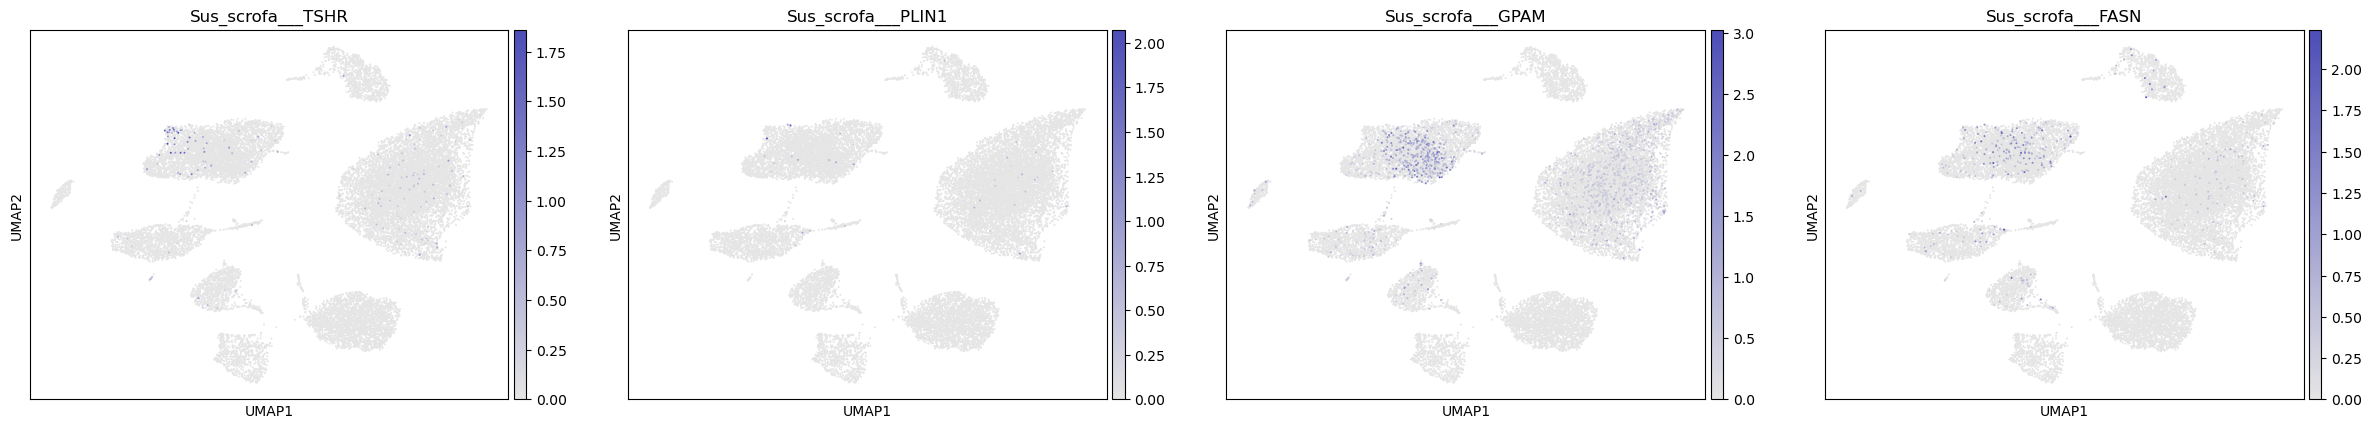

In [ ]:
#######adipocyte
marker=["Sus_scrofa___TSHR", "Sus_scrofa___PLIN1", "Sus_scrofa___GPAM", "Sus_scrofa___FASN"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

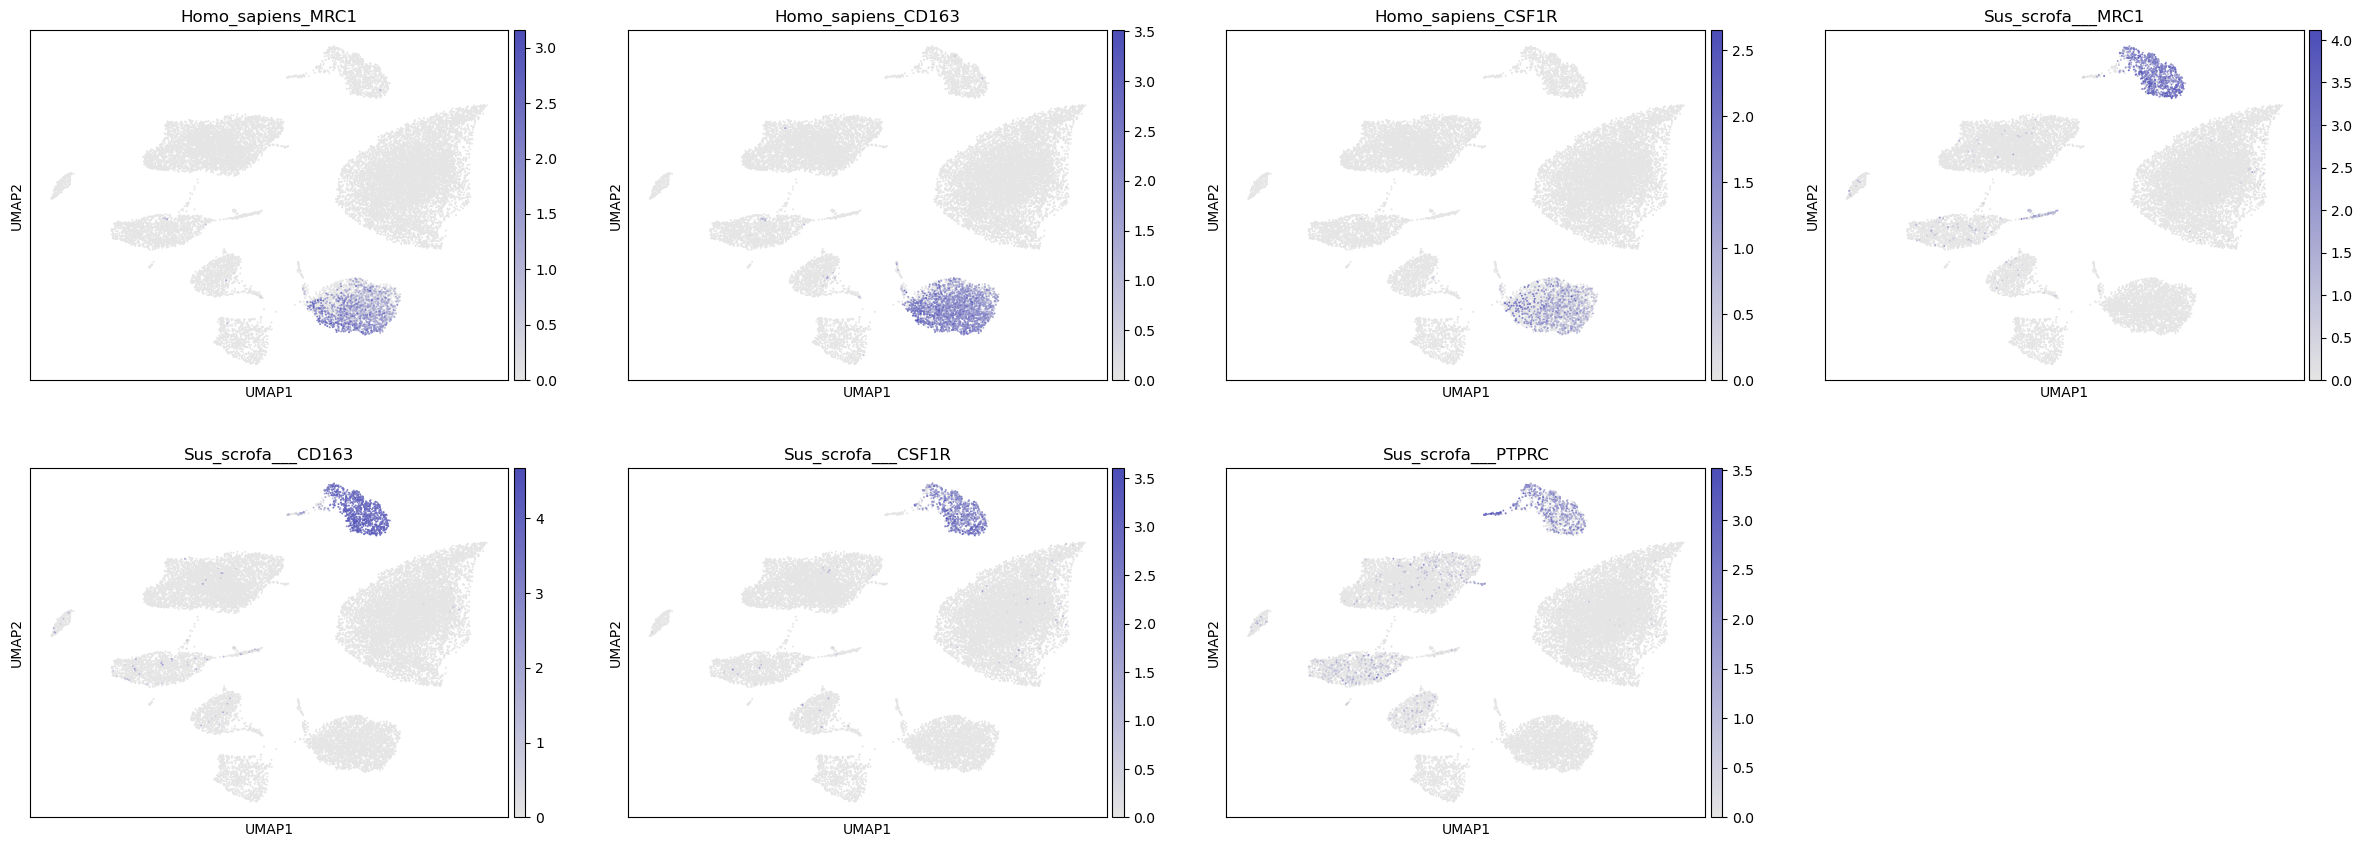

In [ ]:
#######macrophage
marker=["Homo_sapiens_MRC1", "Homo_sapiens_CD163", "Homo_sapiens_CSF1R", "Sus_scrofa___MRC1", "Sus_scrofa___CD163", "Sus_scrofa___CSF1R", "Sus_scrofa___PTPRC"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

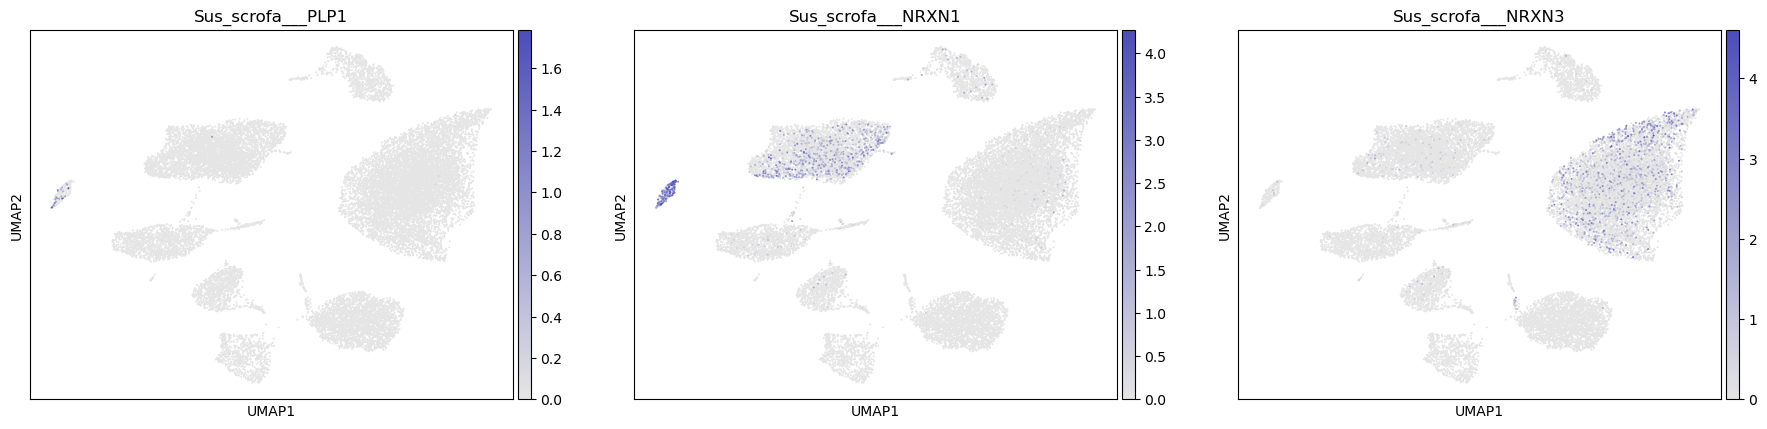

In [ ]:
#######neuron
marker=["Sus_scrofa___PLP1", "Sus_scrofa___NRXN1", "Sus_scrofa___NRXN3"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

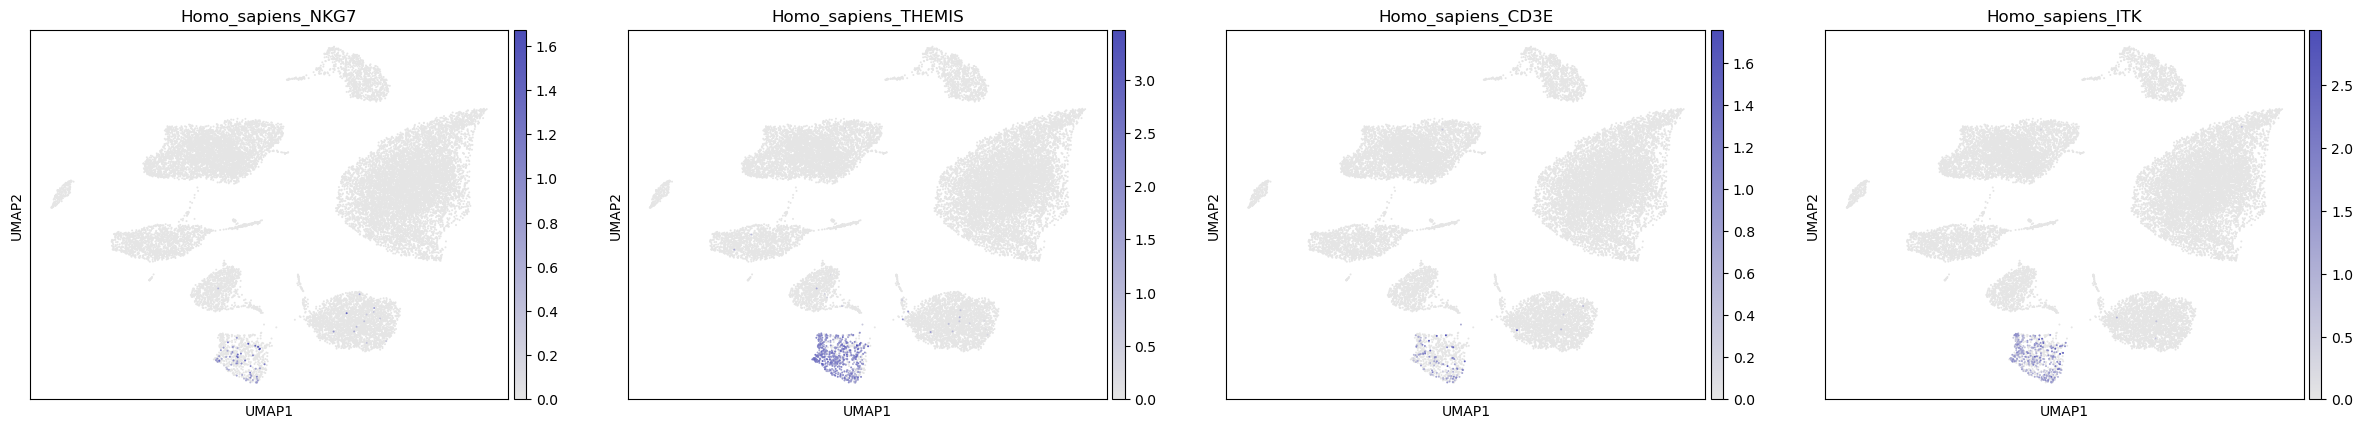

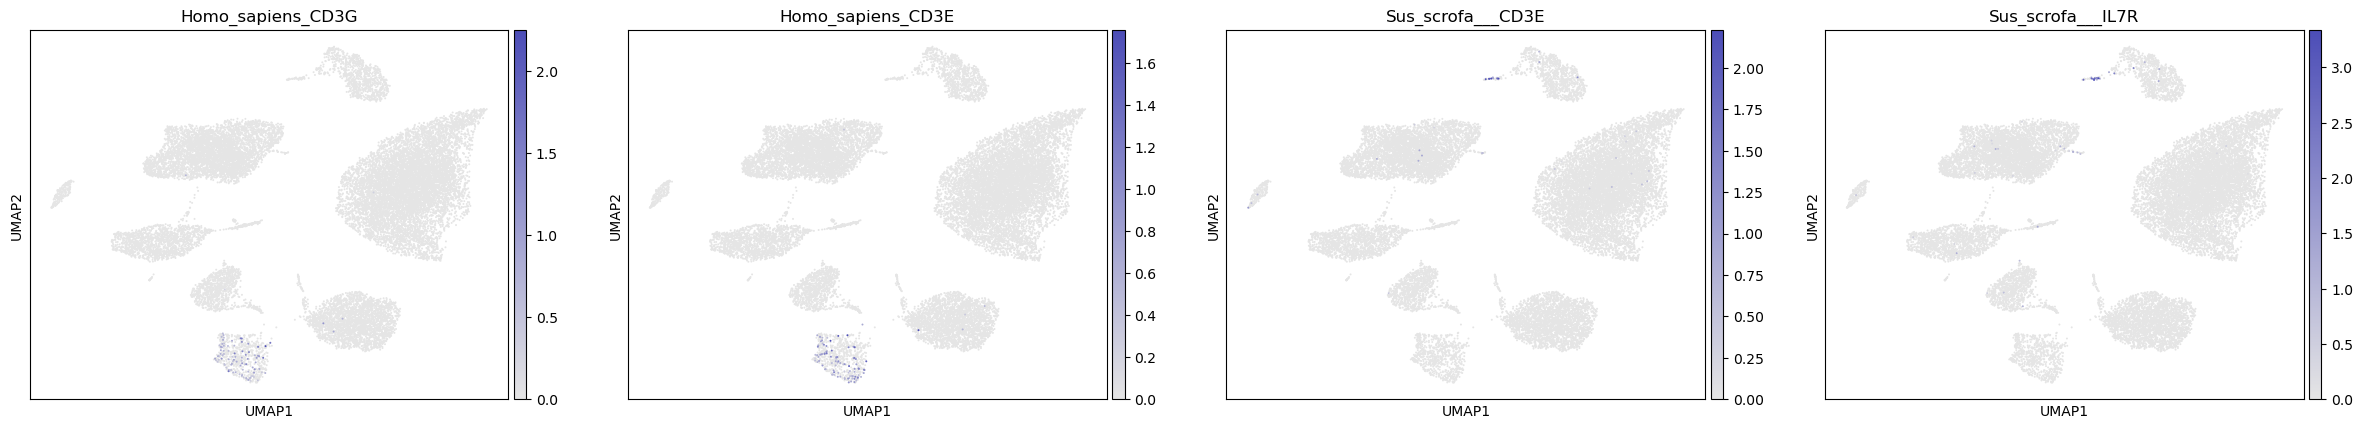

In [ ]:
#######T
marker=["Homo_sapiens_NKG7", "Homo_sapiens_THEMIS", "Homo_sapiens_CD3E", "Homo_sapiens_ITK"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

#######lymphoid
marker=["Homo_sapiens_CD3G", "Homo_sapiens_CD3E", "Sus_scrofa___CD3E", "Sus_scrofa___IL7R"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

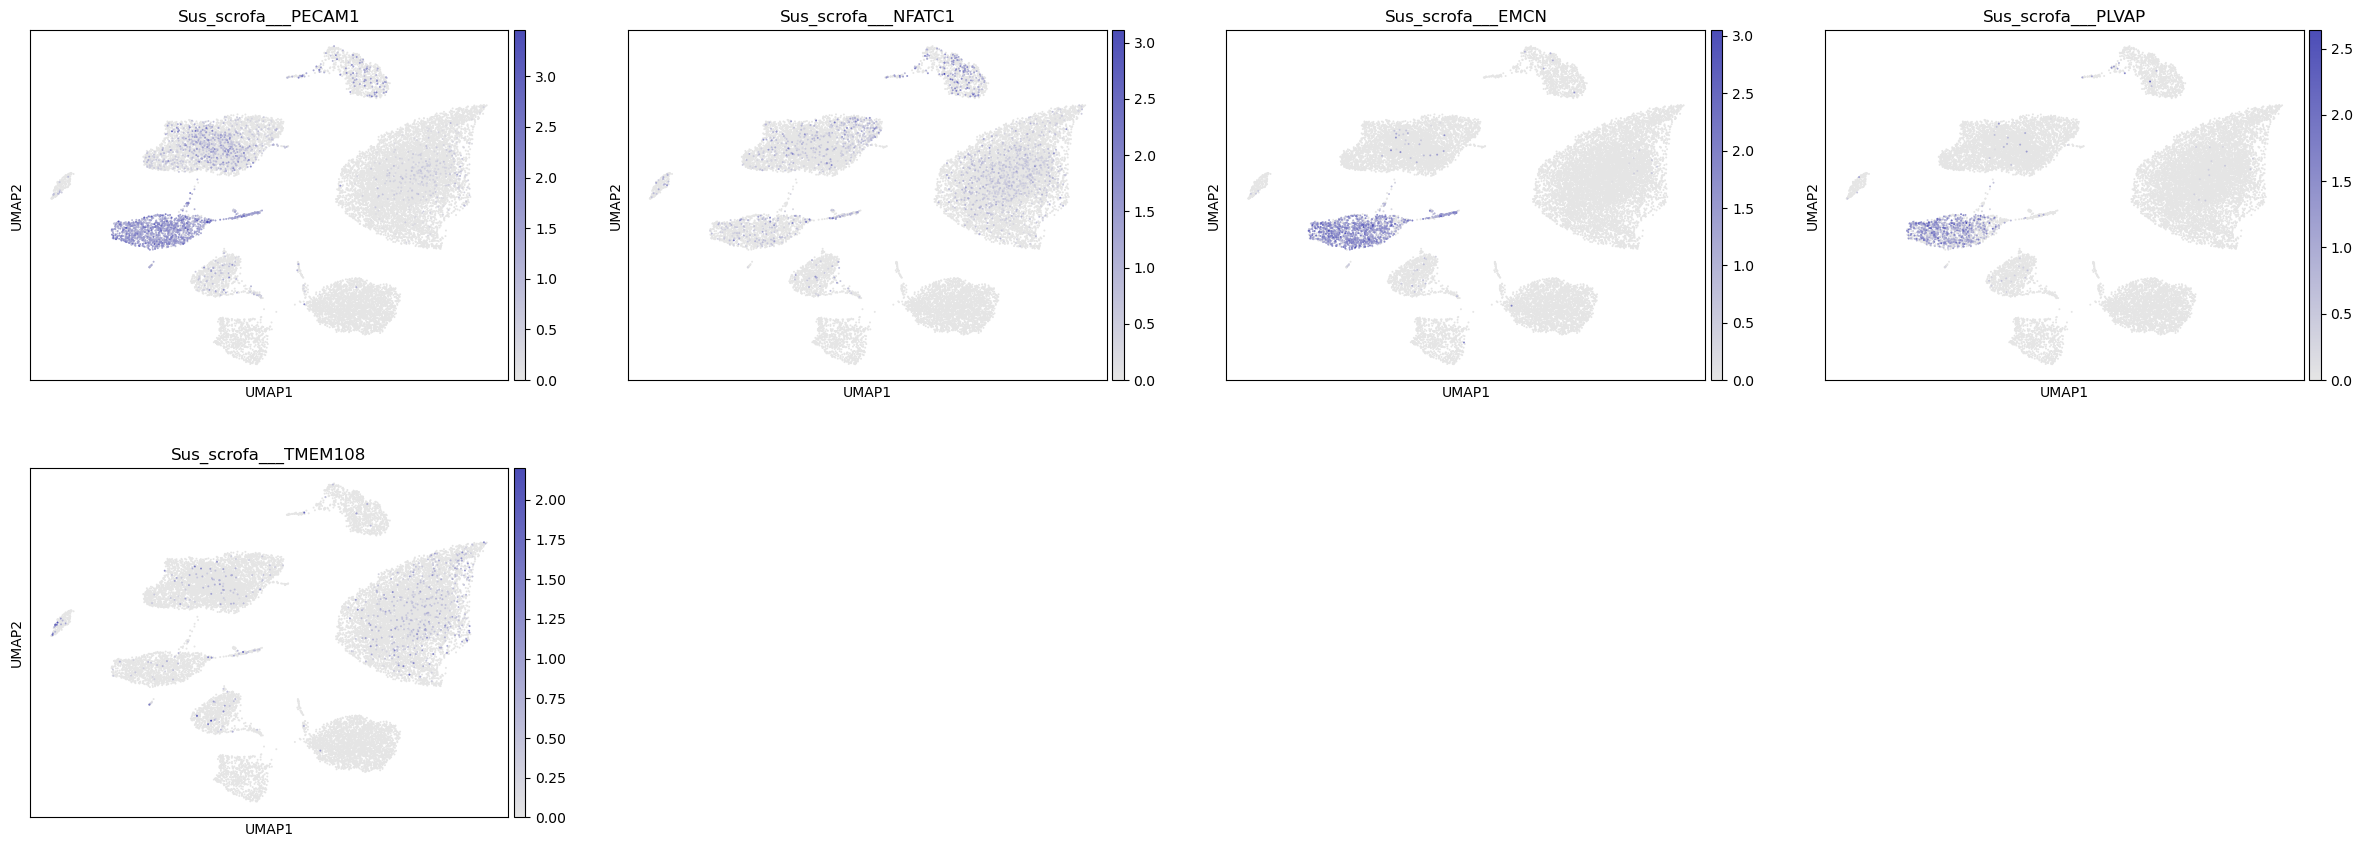

In [ ]:
#######endocardial
marker=["Sus_scrofa___PECAM1", "Sus_scrofa___NFATC1", "Sus_scrofa___EMCN", "Sus_scrofa___PLVAP", "Sus_scrofa___TMEM108"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

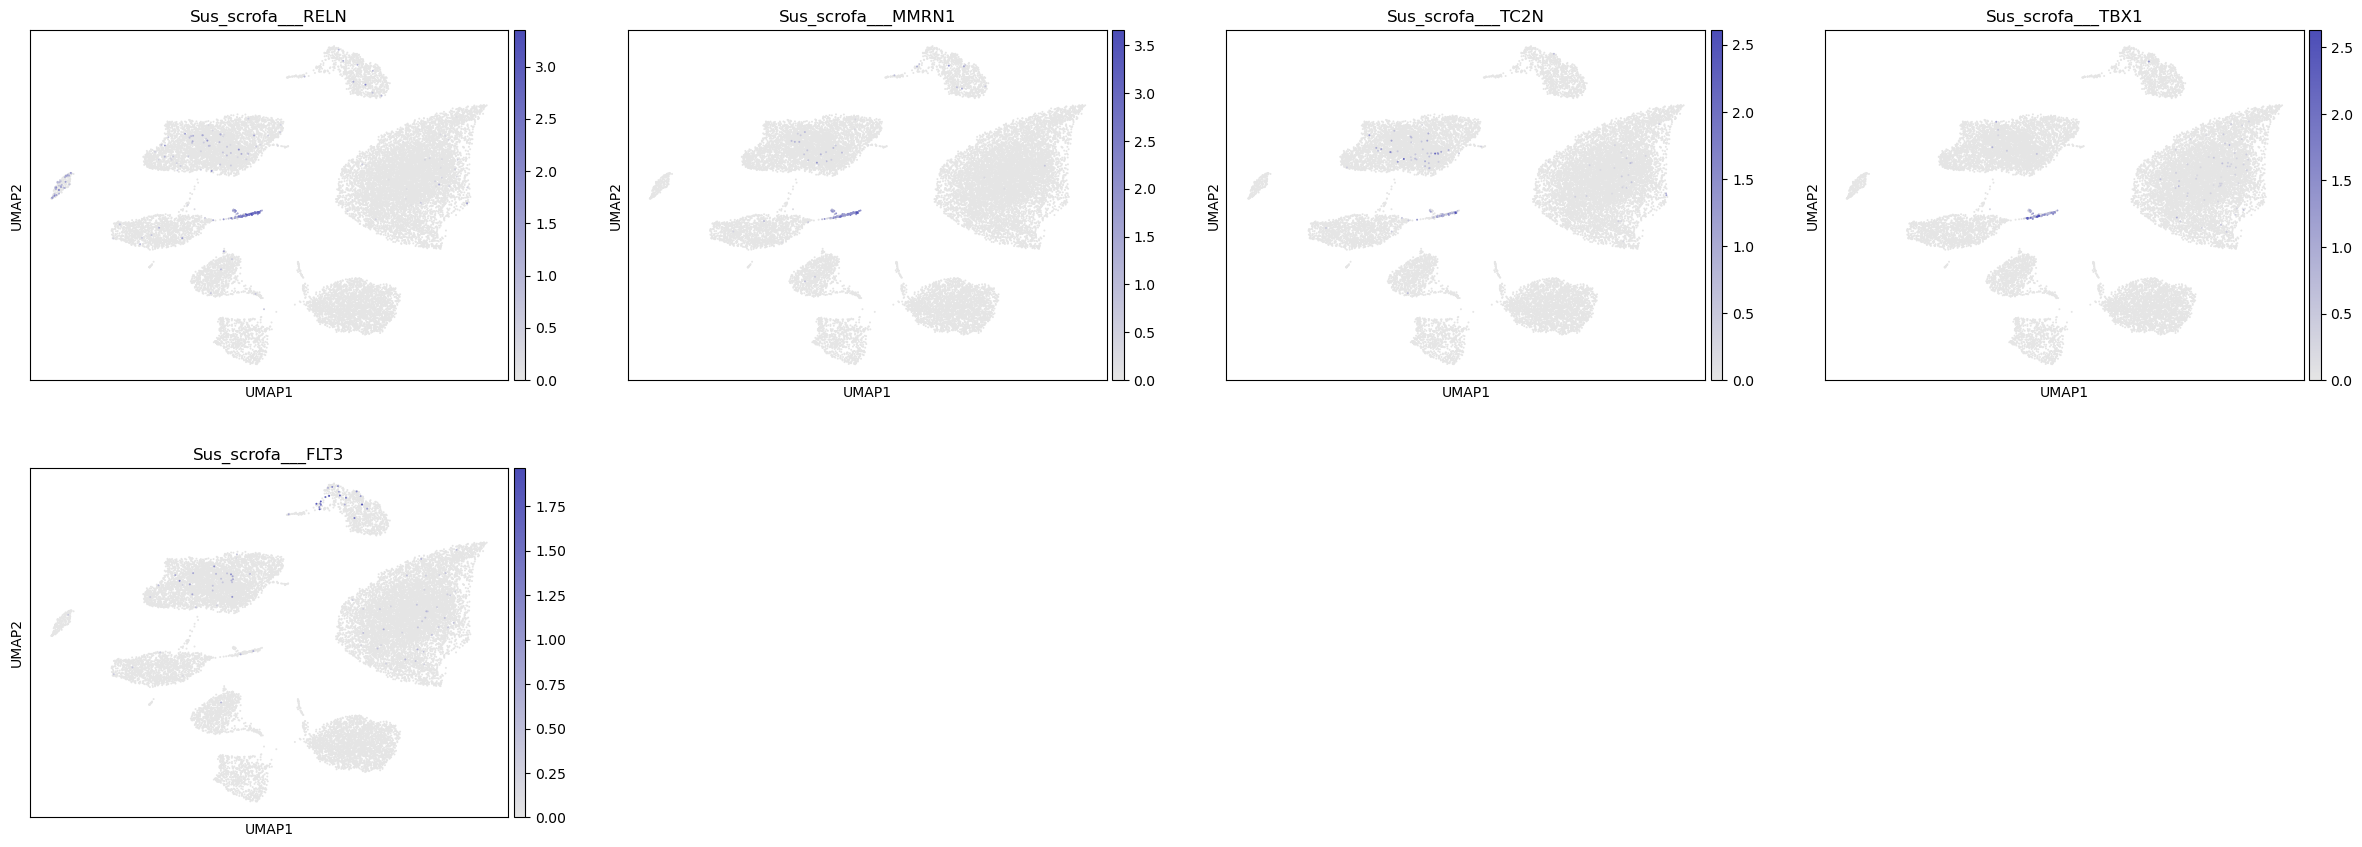

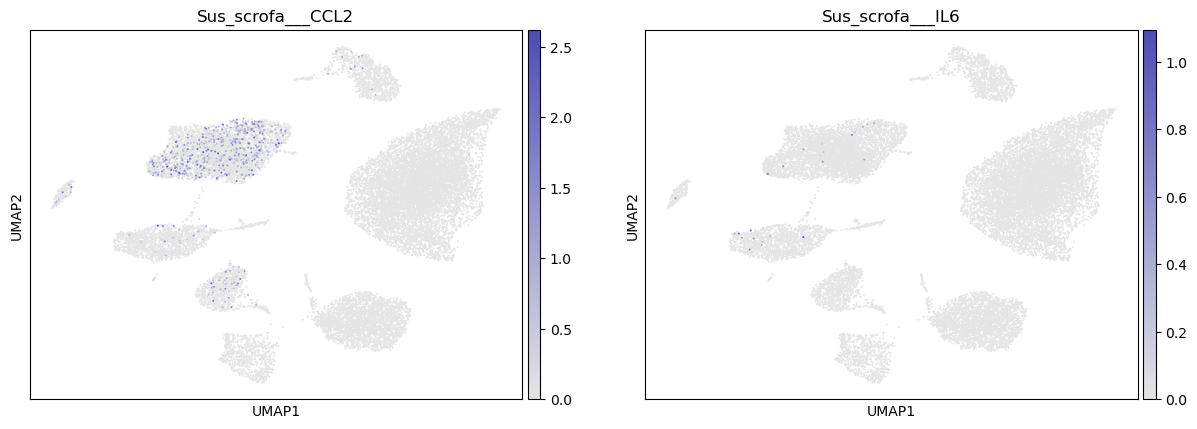

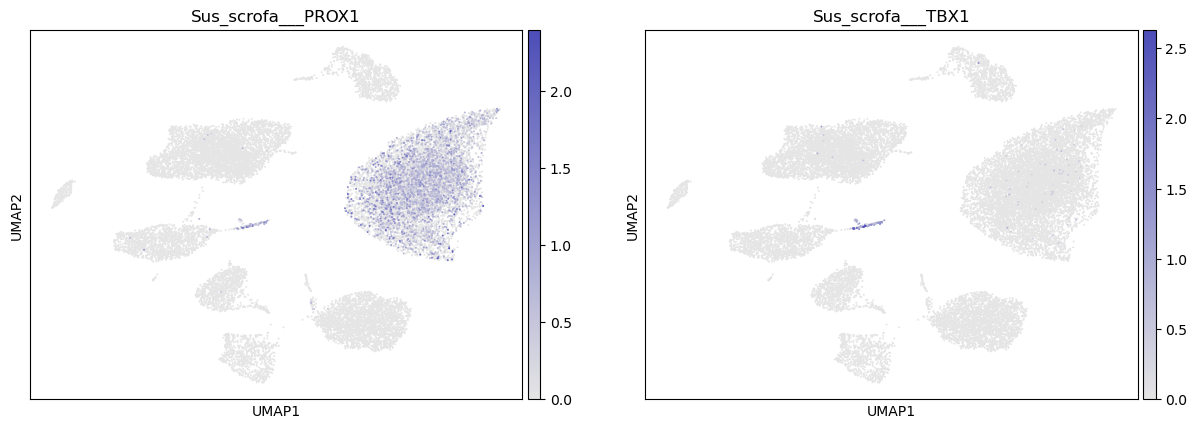

In [ ]:
#######LEC
marker=["Sus_scrofa___RELN", "Sus_scrofa___MMRN1", "Sus_scrofa___TC2N", "Sus_scrofa___TBX1", "Sus_scrofa___FLT3"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

#######EC4 immune-related
marker=[ "Sus_scrofa___CCL2", "Sus_scrofa___IL6"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

#######EC8_ln, lymphatic ECs
marker=["Sus_scrofa___PROX1", "Sus_scrofa___TBX1"]
sc.pl.umap(adata_afterinte, color=marker, cmap=dimplot_color, size=8, legend_fontsize = 6)

## 4. Annotation

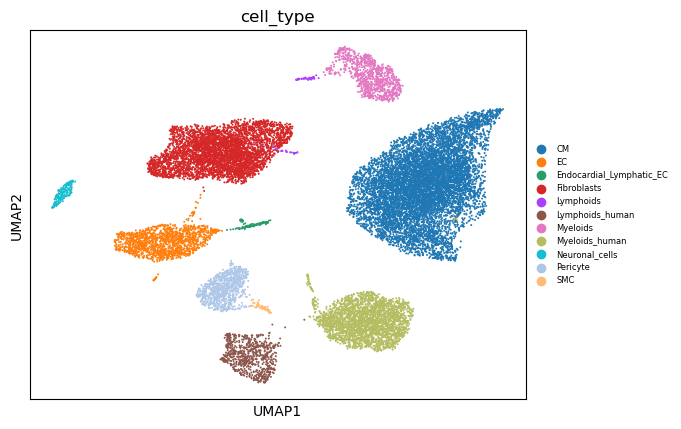

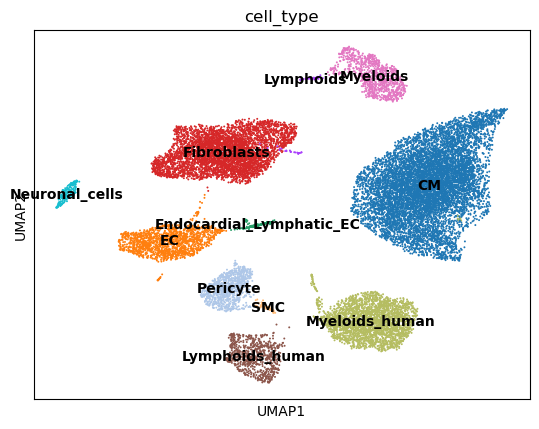

In [ ]:
cluster_to_celltype = {
    '0': 'Fibroblasts',
    '1': 'Myeloids_human',
    '2': 'CM',
    '3': 'CM',
    '4': 'EC',
    '5': 'CM', 
    '6': 'CM',
    '7': 'CM',
    '8': 'CM',
    '9': 'Myeloids',
    '10': 'Pericyte',
    '11': 'Fibroblasts',
    '12': 'Fibroblasts',
    '13': 'Lymphoids_human',
    '14': 'CM',
    '15': 'Neuronal_cells',
    '16': 'Endocardial_Lymphatic_EC',
    '17': 'Fibroblasts',
    '18': 'Myeloids_human',
    '19': 'Lymphoids',
    '20': 'SMC',
    '21': 'EC'
}


# Create a new column in adata.obs to store the renamed clusters
adata_afterinte.obs['cell_type'] = adata_afterinte.obs['leiden_10'].map(cluster_to_celltype)
sc.pl.umap(adata_afterinte, color=["cell_type"], size = 8, legend_fontsize = 6)
sc.pl.umap(adata_afterinte, color=["cell_type"], size = 8, legend_loc="on data")

categories: 0, 1, 2, etc.
var_group_labels: Cardiomyocytes, Fibroblasts, Macrophages/Monocytes, etc.


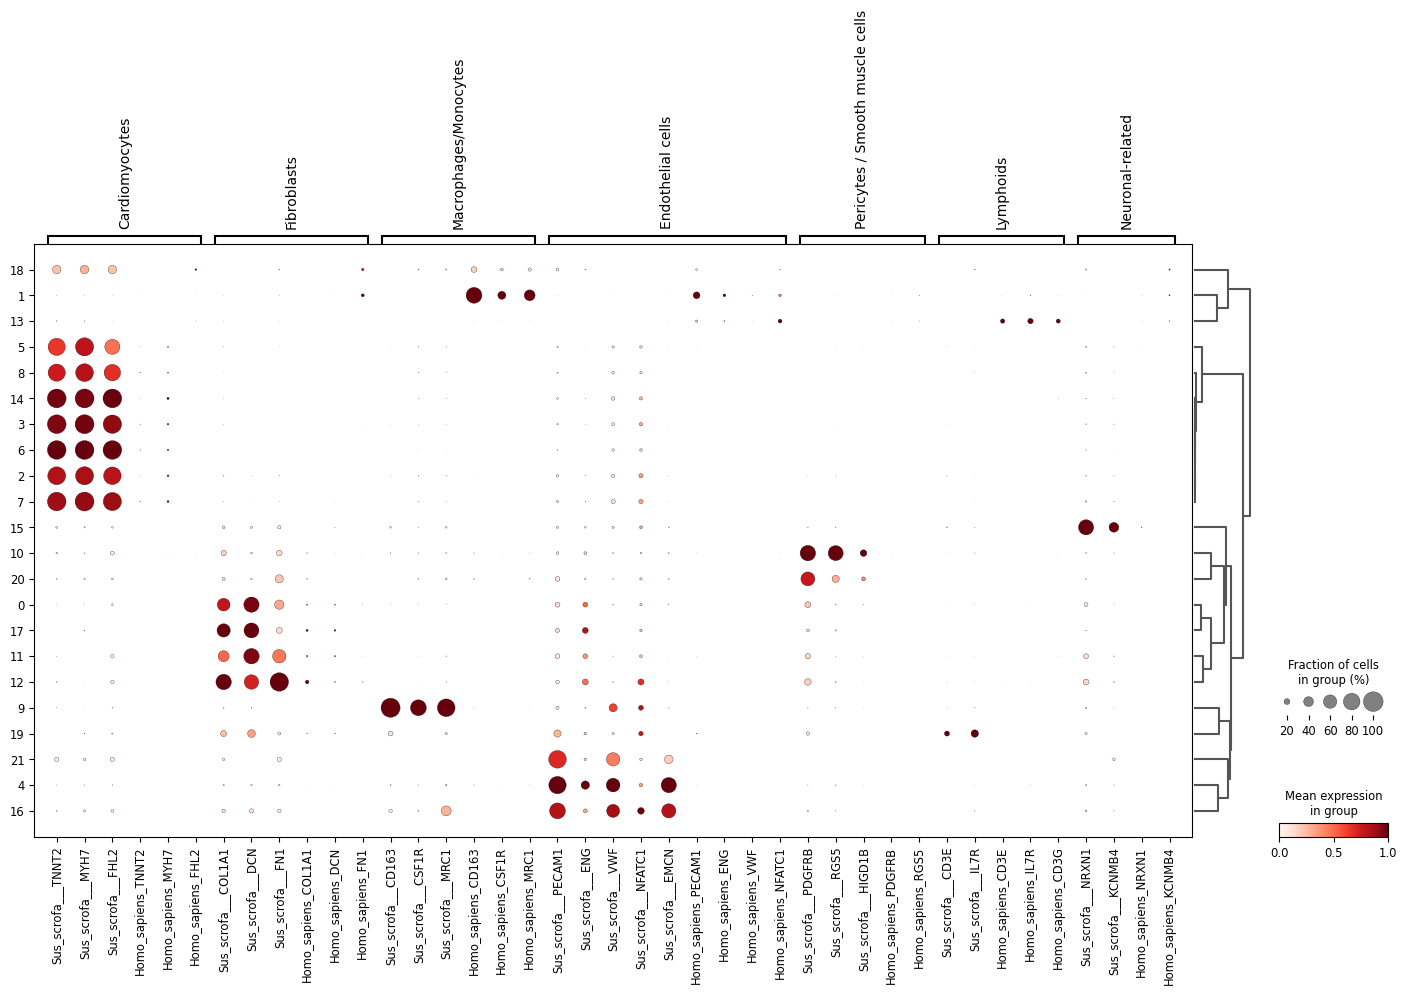

categories: CM, EC, Endocardial_Lymphatic_EC, etc.
var_group_labels: Cardiomyocytes, Fibroblasts, Macrophages/Monocytes, etc.


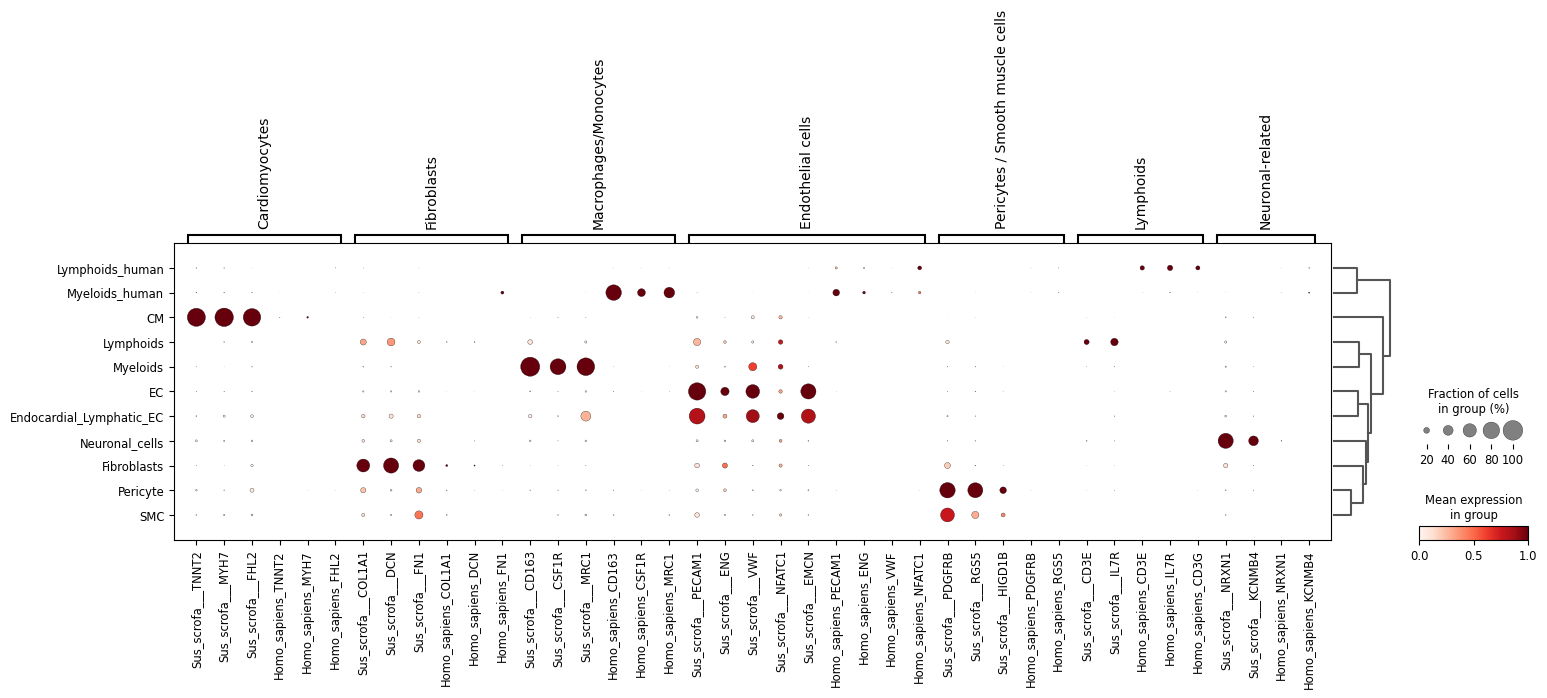

In [ ]:
marker_genes_dict = {
    "Cardiomyocytes": [
        "Sus_scrofa___TNNT2", "Sus_scrofa___MYH7", "Sus_scrofa___FHL2",
        "Homo_sapiens_TNNT2", "Homo_sapiens_MYH7", "Homo_sapiens_FHL2",
    ],
    "Fibroblasts": [
        "Sus_scrofa___COL1A1", "Sus_scrofa___DCN", "Sus_scrofa___FN1",
        "Homo_sapiens_COL1A1", "Homo_sapiens_DCN", "Homo_sapiens_FN1",
    ],
    "Macrophages/Monocytes": [
        "Sus_scrofa___CD163", "Sus_scrofa___CSF1R", "Sus_scrofa___MRC1",
        "Homo_sapiens_CD163", "Homo_sapiens_CSF1R", "Homo_sapiens_MRC1",
    ],
    "Endothelial cells": [
        "Sus_scrofa___PECAM1", "Sus_scrofa___ENG", "Sus_scrofa___VWF",
        "Sus_scrofa___NFATC1", "Sus_scrofa___EMCN",
        "Homo_sapiens_PECAM1", "Homo_sapiens_ENG", "Homo_sapiens_VWF",
        "Homo_sapiens_NFATC1",
    ],
    "Pericytes / Smooth muscle cells": [
        "Sus_scrofa___PDGFRB", "Sus_scrofa___RGS5", "Sus_scrofa___HIGD1B",
        "Homo_sapiens_PDGFRB", "Homo_sapiens_RGS5",
    ],
    "Lymphoids": [
        "Sus_scrofa___CD3E", "Sus_scrofa___IL7R",
        "Homo_sapiens_CD3E", "Homo_sapiens_IL7R", "Homo_sapiens_CD3G",
    ],
    "Neuronal-related": [
        "Sus_scrofa___NRXN1", "Sus_scrofa___KCNMB4",
        "Homo_sapiens_NRXN1", "Homo_sapiens_KCNMB4",
    ],
}

#sc.pl.dotplot(adata_afterinte, marker_genes_dict, "cell_type", dendrogram=True, log=True, standard_scale="var")
sc.pl.dotplot(adata_afterinte, marker_genes_dict, "leiden_10", dendrogram=True, log=True, standard_scale="var")
sc.pl.dotplot(adata_afterinte, marker_genes_dict, "cell_type", dendrogram=True, log=True, standard_scale="var")

categories: 328_1, 443_2, 535_2
var_group_labels: Immediate-early, Early, Late


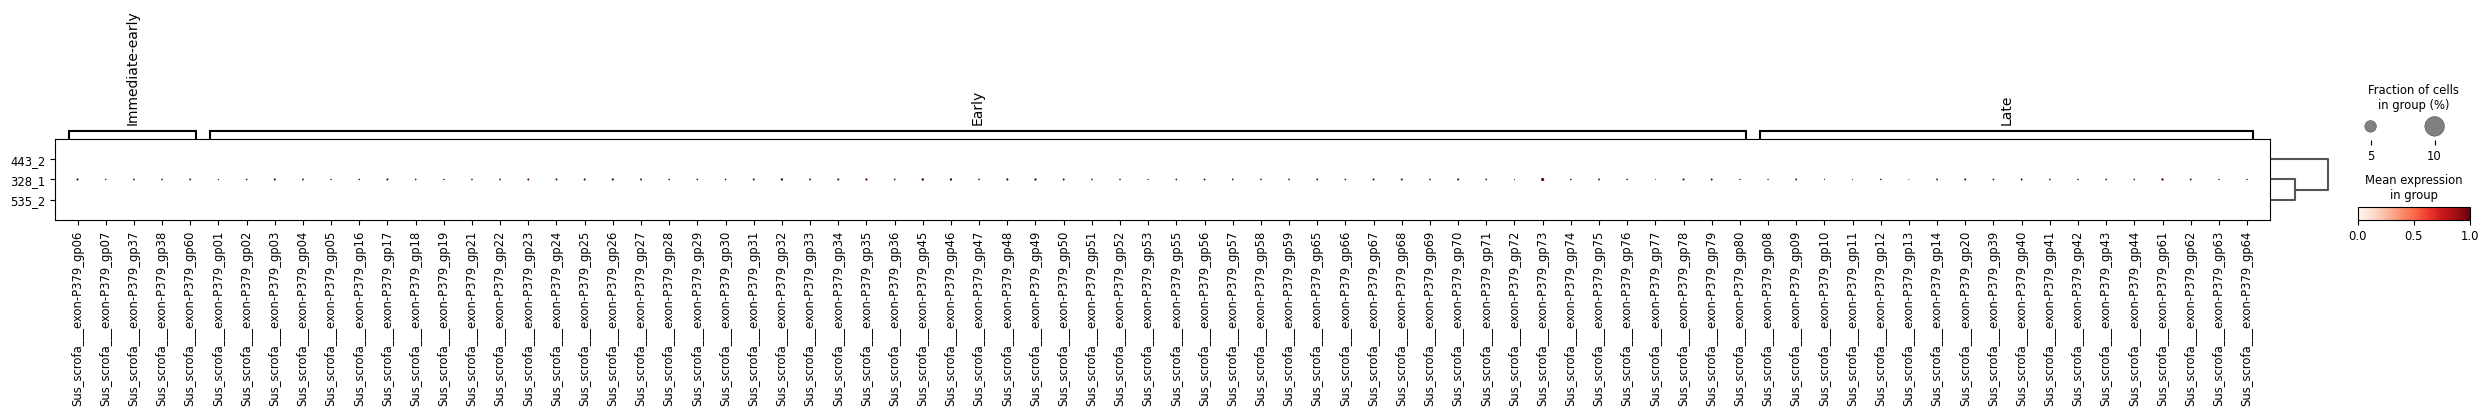

In [ ]:
########all marker expression
marker_genes_dict = {
    "Immediate-early": [
"Sus_scrofa___exon-P379_gp06",
"Sus_scrofa___exon-P379_gp07",
"Sus_scrofa___exon-P379_gp37",
"Sus_scrofa___exon-P379_gp38",
"Sus_scrofa___exon-P379_gp60"
],
    "Early": [
"Sus_scrofa___exon-P379_gp01",
"Sus_scrofa___exon-P379_gp02",
"Sus_scrofa___exon-P379_gp03",
"Sus_scrofa___exon-P379_gp04",
"Sus_scrofa___exon-P379_gp05",
"Sus_scrofa___exon-P379_gp16",
"Sus_scrofa___exon-P379_gp17",
"Sus_scrofa___exon-P379_gp18",
"Sus_scrofa___exon-P379_gp19",
"Sus_scrofa___exon-P379_gp21",
"Sus_scrofa___exon-P379_gp22",
"Sus_scrofa___exon-P379_gp23",
"Sus_scrofa___exon-P379_gp24",
"Sus_scrofa___exon-P379_gp25",
"Sus_scrofa___exon-P379_gp26",
"Sus_scrofa___exon-P379_gp27",
"Sus_scrofa___exon-P379_gp28",
"Sus_scrofa___exon-P379_gp29",
"Sus_scrofa___exon-P379_gp30",
"Sus_scrofa___exon-P379_gp31",
"Sus_scrofa___exon-P379_gp32",
"Sus_scrofa___exon-P379_gp33",
"Sus_scrofa___exon-P379_gp34",
"Sus_scrofa___exon-P379_gp35",
"Sus_scrofa___exon-P379_gp36",
"Sus_scrofa___exon-P379_gp45",
"Sus_scrofa___exon-P379_gp46",
"Sus_scrofa___exon-P379_gp47",
"Sus_scrofa___exon-P379_gp48",
"Sus_scrofa___exon-P379_gp49",
"Sus_scrofa___exon-P379_gp50",
"Sus_scrofa___exon-P379_gp51",
"Sus_scrofa___exon-P379_gp52",
"Sus_scrofa___exon-P379_gp53",
"Sus_scrofa___exon-P379_gp55",
"Sus_scrofa___exon-P379_gp56",
"Sus_scrofa___exon-P379_gp57",
"Sus_scrofa___exon-P379_gp58",
"Sus_scrofa___exon-P379_gp59",
"Sus_scrofa___exon-P379_gp65",
"Sus_scrofa___exon-P379_gp66",
"Sus_scrofa___exon-P379_gp67",
"Sus_scrofa___exon-P379_gp68",
"Sus_scrofa___exon-P379_gp69",
"Sus_scrofa___exon-P379_gp70",
"Sus_scrofa___exon-P379_gp71",
"Sus_scrofa___exon-P379_gp72",
"Sus_scrofa___exon-P379_gp73",
"Sus_scrofa___exon-P379_gp74",
"Sus_scrofa___exon-P379_gp75",
"Sus_scrofa___exon-P379_gp76",
"Sus_scrofa___exon-P379_gp77",
"Sus_scrofa___exon-P379_gp78",
"Sus_scrofa___exon-P379_gp79",
"Sus_scrofa___exon-P379_gp80"
],
    "Late": [
"Sus_scrofa___exon-P379_gp08",
"Sus_scrofa___exon-P379_gp09",
"Sus_scrofa___exon-P379_gp10",
"Sus_scrofa___exon-P379_gp11",
"Sus_scrofa___exon-P379_gp12",
"Sus_scrofa___exon-P379_gp13",
"Sus_scrofa___exon-P379_gp14",
"Sus_scrofa___exon-P379_gp20",
"Sus_scrofa___exon-P379_gp39",
"Sus_scrofa___exon-P379_gp40",
"Sus_scrofa___exon-P379_gp41",
"Sus_scrofa___exon-P379_gp42",
"Sus_scrofa___exon-P379_gp43",
"Sus_scrofa___exon-P379_gp44",
"Sus_scrofa___exon-P379_gp61",
"Sus_scrofa___exon-P379_gp62",
"Sus_scrofa___exon-P379_gp63",
"Sus_scrofa___exon-P379_gp64"
]
}
#sc.pl.dotplot(adata_afterinte, marker_genes_dict, "cell_type", dendrogram=True, log=True, standard_scale="var")
sc.pl.dotplot(adata_afterinte, marker_genes_dict, "sample", dendrogram=True, log=True, standard_scale="var")

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_31462/883009320.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expression_per_sample = expression_df.groupby('Sample')[genes_to_plot].mean()


Generated plot: gene_mean_dist_boxplot_Immediate-early.png


/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 25.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Generated plot: gene_mean_dist_boxplot_Early.png
Generated plot: gene_mean_dist_boxplot_Late.png


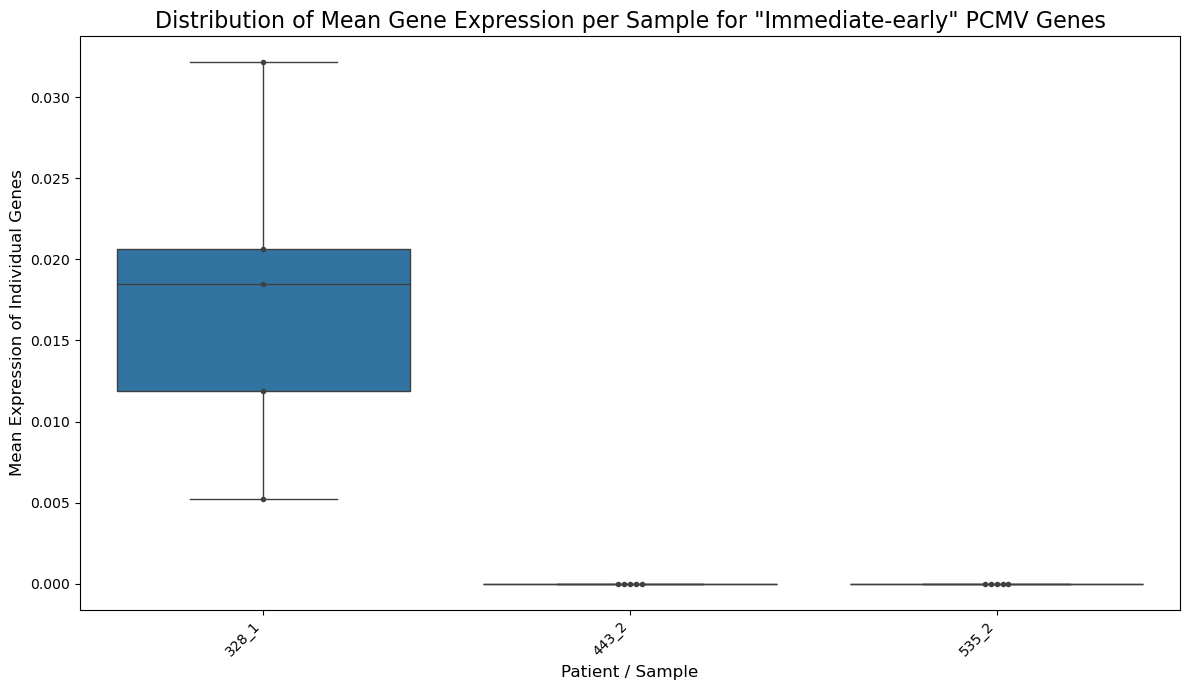

/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


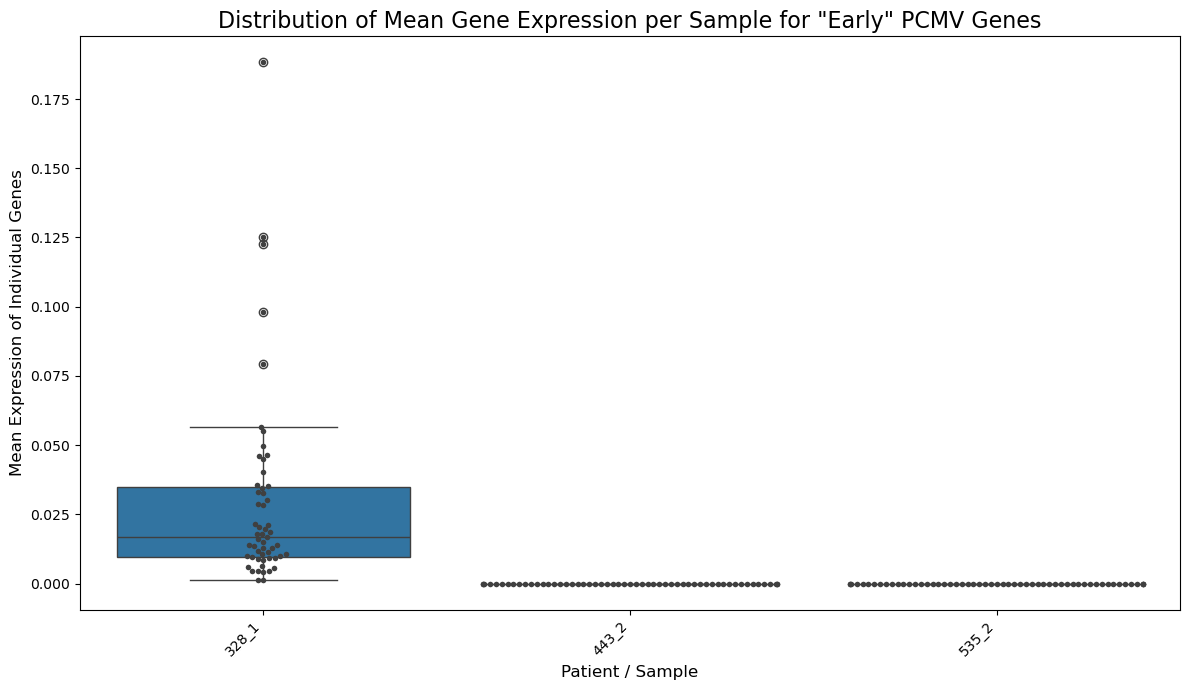

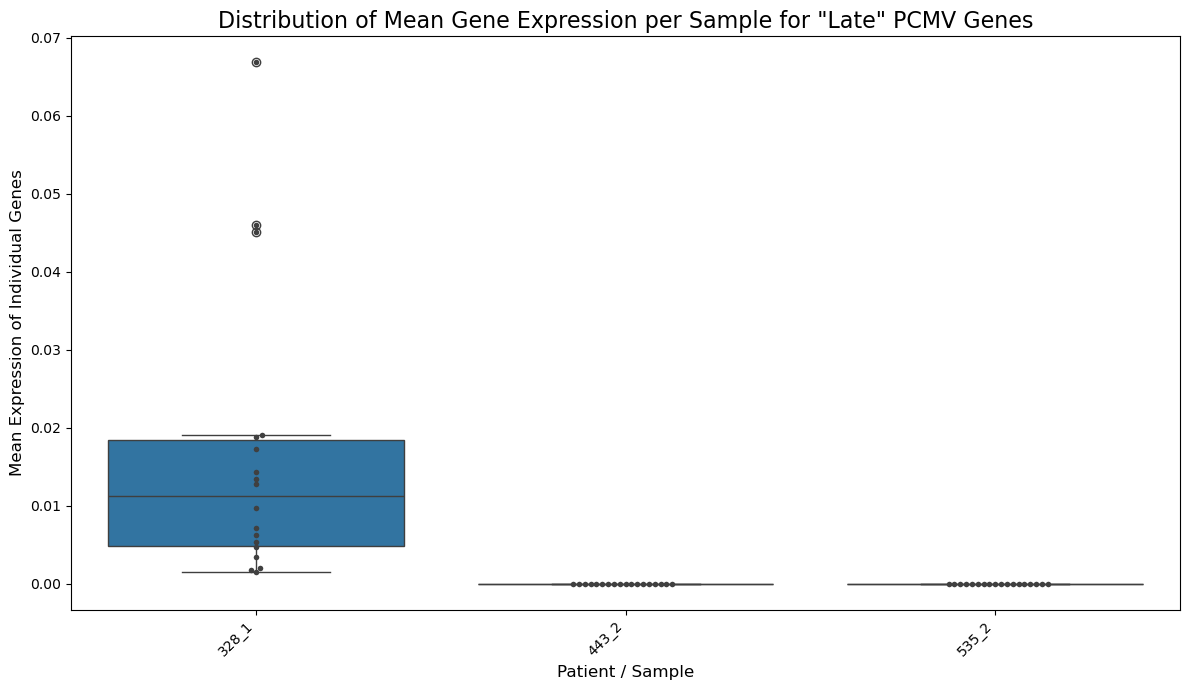

In [ ]:
# --- 1. Extract and aggregate data from your AnnData object ---
all_genes = [gene for gene_list in marker_genes_dict.values() for gene in gene_list]
genes_to_plot = [gene for gene in all_genes if gene in adata.var_names]
expression_df = adata[:, genes_to_plot].to_df()
expression_df['Sample'] = adata.obs['sample'].values

# Calculate the MEAN expression of each gene for each sample
mean_expression_per_sample = expression_df.groupby('Sample')[genes_to_plot].mean()

# --- 2. Loop through each group and create a plot ---
for group_name, gene_list in marker_genes_dict.items():
    genes_in_group = [gene for gene in gene_list if gene in genes_to_plot]
    
    if not genes_in_group:
        print(f"Skipping group '{group_name}' as no genes were found in the data.")
        continue

    # Select the mean expression data for the current group of genes
    group_mean_df = mean_expression_per_sample[genes_in_group]
    
    # Reshape the data for plotting: each row will be a single gene's mean expression in a specific sample
    df_long = group_mean_df.melt(var_name='Gene', value_name='Mean Expression', ignore_index=False)
    df_long = df_long.reset_index() # Move 'Sample' from index to a column

    # --- 3. Create and save the box plot ---
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_long, x='Sample', y='Mean Expression')
    
    # Optional: Add a swarmplot to show the individual gene points
    sns.swarmplot(data=df_long, x='Sample', y='Mean Expression', color=".25", size=4)
    
    # Add titles and labels
    plt.title(f'Distribution of Mean Gene Expression per Sample for "{group_name}" PCMV Genes', fontsize=16)
    plt.xlabel('Patient / Sample', fontsize=12)
    plt.ylabel('Mean Expression of Individual Genes', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save the figure
    filename = f'gene_mean_dist_boxplot_{group_name}.png'
    plt.savefig(filename)
    print(f"Generated plot: {filename}")

In [ ]:
#######save preprocessed data
adata_afterinte.write(output_path+"Humanxeno_annot.h5ad")
adata.write(output_path+"Humanxeno_raw.h5ad")

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_31462/3333974785.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_counts = adata_afterinte.obs.groupby(['sample', 'cell_type']).size().unstack(fill_value=0)


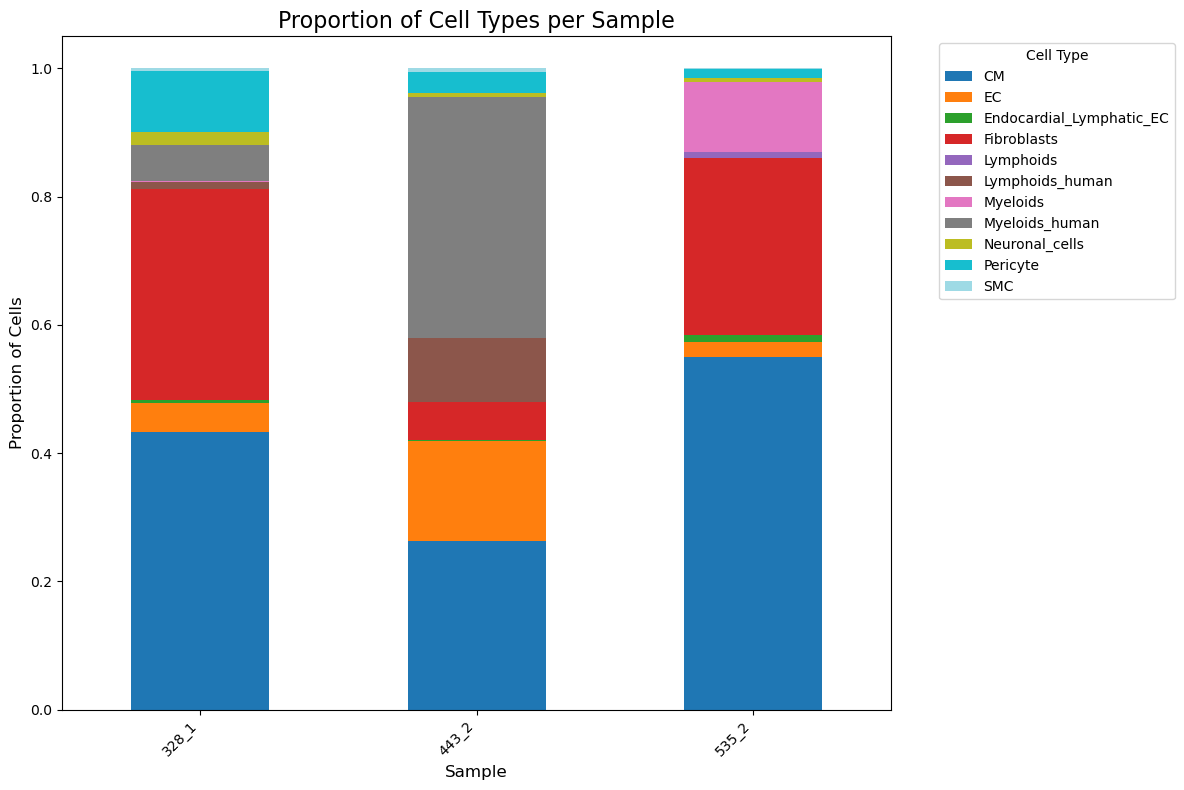

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the cell counts per sample and cell type
# Assuming adata_afterinte is your AnnData object
cell_type_counts = adata_afterinte.obs.groupby(['sample', 'cell_type']).size().unstack(fill_value=0)

# 2. Calculate the proportions for each sample
proportions = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0)

# 3. Create the stacked bar chart with a new colormap
# You can use a different colormap like 'viridis', 'plasma', 'tab20b', etc.
proportions.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab20')

# 4. Add titles and labels
plt.title('Proportion of Cell Types per Sample', fontsize=16)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Proportion of Cells', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Show the plot
plt.tight_layout()
plt.show()